# REPORT plots (thesis figures) aide

Contains extensive results used to create the storyline.

Unified report figures across **MNIST**, **CIFAR Inception**, and **CIFAR ResNet** (one row per model).

- Cached analysis: `results_analysis/mnist/` and `results_analysis/cifar/`
- Output: `local/save/plots/report/`
- Plot 1 uses **seed 3003** runs only (raw period counts, no SEM)
- Plot 2: total BSS $BSS(b_i)$ (mean ± 1.96·SEM bars + per-experiment boxplots)
- Plots 3–6: period metrics (length, angle, robustness, $t_\mathrm{start}$)
- Plots 7–8: optimizer performance from training loss (peak magnitude, TTC)
- Plot 9: spider profiles (five axes; optional angle; one figure per model)
- Plot 9b: pooled spider (shuffle-seq / recover / reinforce; one row × three models)
- Plot 10: $t_\mathrm{start}$ offset from novelty (Cat2 pooled eCDF + AUC / two-sample Cramér–von Mises vs neuro BTSP)
- Plot 11: layer-wise analysis (pooled Cat2 non-control): BTSP neuron % / period % and BSS per layer
- Training Losses: windowed pretrain curves (always shown + saved); per-experiment loss with peaks/thresholds (`SAVEplot`)
- Significance brackets follow `single_room_multi_opt` (`SHOW_SIGNIFICANCE`, `SHOW_INSIGNIFICANCE`)


In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import sys
from pathlib import Path
from typing import Iterable

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def _find_project_root(start: Path | None = None) -> Path:
	p = (start or Path.cwd()).resolve()
	for cand in [p, *p.parents]:
		if (cand / "pyproject.toml").is_file():
			return cand
	return p


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(PROJECT_ROOT))

from analysis.final.final_analysis_config import (
	DEFAULT_SCORE_FACTORS,
	EXPERT_MODEL_DIR_BY_DATASET,
	save_dir_for_dataset,
)
from analysis.final.final_compare_all_optimizers_helpers import (
	build_df_counts,
	build_df_long,
	build_period_novelty_offset_df,
	load_neuro_experimental_bars,
	robustness_long_metric_name,
)
from analysis.final.final_experiment_display import (
	ExperimentDisplayLabels,
	experiment_display_sort_rank,
	normalize_experiment_display_label,
	rename_experiments_for_labels,
	sort_experiment_display_names,
)
from analysis.final.load_final_analysis import run_final_analysis
from analysis.final.report_plots.aide_helper import (
	build_report_spider_means,
	plot_report_layerwise_bss_figure,
	plot_report_layerwise_btsp_pct_figure,
	plot_report_metric_figure,
	plot_report_period_count_figure,
	plot_report_pretrain_loss_figures,
	plot_report_spider_figure,
	plot_report_spider_pooled_figure,
	plot_report_stabilization_loss_figures,
	plot_report_t_start_comparison_figure,
)
from analysis.final.report_optimizer_performance_helper import (
	build_report_peak_ratio_long,
	build_report_ttc_long,
)

sns = __import__("seaborn")
sns.set_theme(context="paper", style="whitegrid", font_scale=1.0)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 200
mpl.rcParams["axes.titlesize"] = 10
mpl.rcParams["axes.labelsize"] = 8
mpl.rcParams["xtick.labelsize"] = 7
mpl.rcParams["ytick.labelsize"] = 7
mpl.rcParams["legend.fontsize"] = 7
mpl.rcParams["legend.title_fontsize"] = 8

SHOW_SIGNIFICANCE = True
SHOW_INSIGNIFICANCE = True

PLOT_DIR = "local/save/plots/report/"
Path(PLOT_DIR).mkdir(parents=True, exist_ok=True)

N_CHECKPOINT_SAMPLES = 20
SCORE_FACTORS = dict(DEFAULT_SCORE_FACTORS)
SCORE_FACTORS["n_partial_decay_score"] = 0.0
SCORE_FACTORS["n_active_decay_score"] = 0.0
RESCORE = True
MINMAX_NORMALIZE_ROBUSTNESS = True
REPARSE_DIGIT_A = False
STRICT = False
BTSP_START_STRATEGY = "acceleration"
USE_REAL_PROGRESSION = True

_EXPER_LABEL_SHUFFLE_ALL = r"$\text{Shuffle}_{all}$"
_EXPER_LABEL_SHUFFLE_NOPRE = "Control global (✗PT)"
_EXPER_LABEL_SHUFFLE_INTERLEAVED = r"$\text{Shuffle}_{interleaved}$"
_EXPER_LABEL_SEQ_NOPRE = "Control sequential (✗PT)"
_EXPER_LABEL_SEQ_PRE = "Control sequential (✔PT)"
_EXPER_LABEL_SHUFFLE_SEQ = r"$\text{Shuffle}_{seq}$"
_EXPER_LABEL_NO_PRETRAIN = " Control (no pretrain)"

LABELS = ExperimentDisplayLabels(
	shuffle_all=_EXPER_LABEL_SHUFFLE_ALL,
	shuffle_interleaved=_EXPER_LABEL_SHUFFLE_INTERLEAVED,
	shuffle_nopre=_EXPER_LABEL_SHUFFLE_NOPRE,
	seq_nopre=_EXPER_LABEL_SEQ_NOPRE,
	seq_pre=_EXPER_LABEL_SEQ_PRE,
	shuffle_seq=_EXPER_LABEL_SHUFFLE_SEQ,
	no_pretrain=_EXPER_LABEL_NO_PRETRAIN,
)


def rename_experiments(exp_name: str) -> str:
	return normalize_experiment_display_label(
		rename_experiments_for_labels(exp_name, LABELS), LABELS
	)


def _sort_experiment_display_names(labels: Iterable[str]) -> list[str]:
	return sort_experiment_display_names(labels, LABELS)

In [20]:
all_results: dict = {}
all_trees: dict = {}
errors_all: list[dict] = []

for DATASET in ("mnist", "cifar10"):
	SAVE_DIR = str(save_dir_for_dataset(PROJECT_ROOT, DATASET))
	Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
	ar, tree, errors, _ds_key, model_ids = run_final_analysis(
		input_dir=PROJECT_ROOT / "results",
		output_dir=Path(SAVE_DIR),
		project_root=PROJECT_ROOT,
		expert_model_dir=EXPERT_MODEL_DIR_BY_DATASET[DATASET],
		n_checkpoint_samples=N_CHECKPOINT_SAMPLES,
		score_factors=SCORE_FACTORS,
		rescore=RESCORE,
		minmax_normalize_robustness=MINMAX_NORMALIZE_ROBUSTNESS,
		reparse_digit_a=REPARSE_DIGIT_A,
		strict=STRICT,
		btsp_start_strategy=BTSP_START_STRATEGY,
		use_real_progression=USE_REAL_PROGRESSION,
		dataset=DATASET,
		verbose_errors=True,
	)
	all_results.update(ar)
	all_trees[DATASET] = tree
	errors_all.extend(errors or [])
	print(f"DATASET={DATASET} model_ids={model_ids} experiments={len(tree)} runs={len(ar)}")

if errors_all:
	display(pd.DataFrame(errors_all))

df_long = build_df_long(all_results, rename_experiments)
df_counts = build_df_counts(all_results, rename_experiments)
df_peak = build_report_peak_ratio_long(all_results, rename_experiments)
df_ttc = build_report_ttc_long(all_results, rename_experiments)
print(
	f"df_long rows={len(df_long)}  df_counts rows={len(df_counts)}  "
	f"df_peak rows={len(df_peak)}  df_ttc rows={len(df_ttc)}"
)

Experiments:   0%|          | 0/10 [00:00<?, ?it/s]

Robustness already min-max normalized in cached runs; skipped min-max normalization
DATASET=mnist model_ids=['dnn_5x64'] experiments=10 runs=50


Experiments:   0%|          | 0/16 [00:00<?, ?it/s]

Robustness already min-max normalized in cached runs; skipped min-max normalization
DATASET=cifar10 model_ids=['inception_small_dnn_5x64', 'resnet32_dnn_5x64'] experiments=16 runs=100
df_long rows=127346  df_counts rows=150  df_peak rows=2934  df_ttc rows=1357


## 1. Period count

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_period_count.pdf


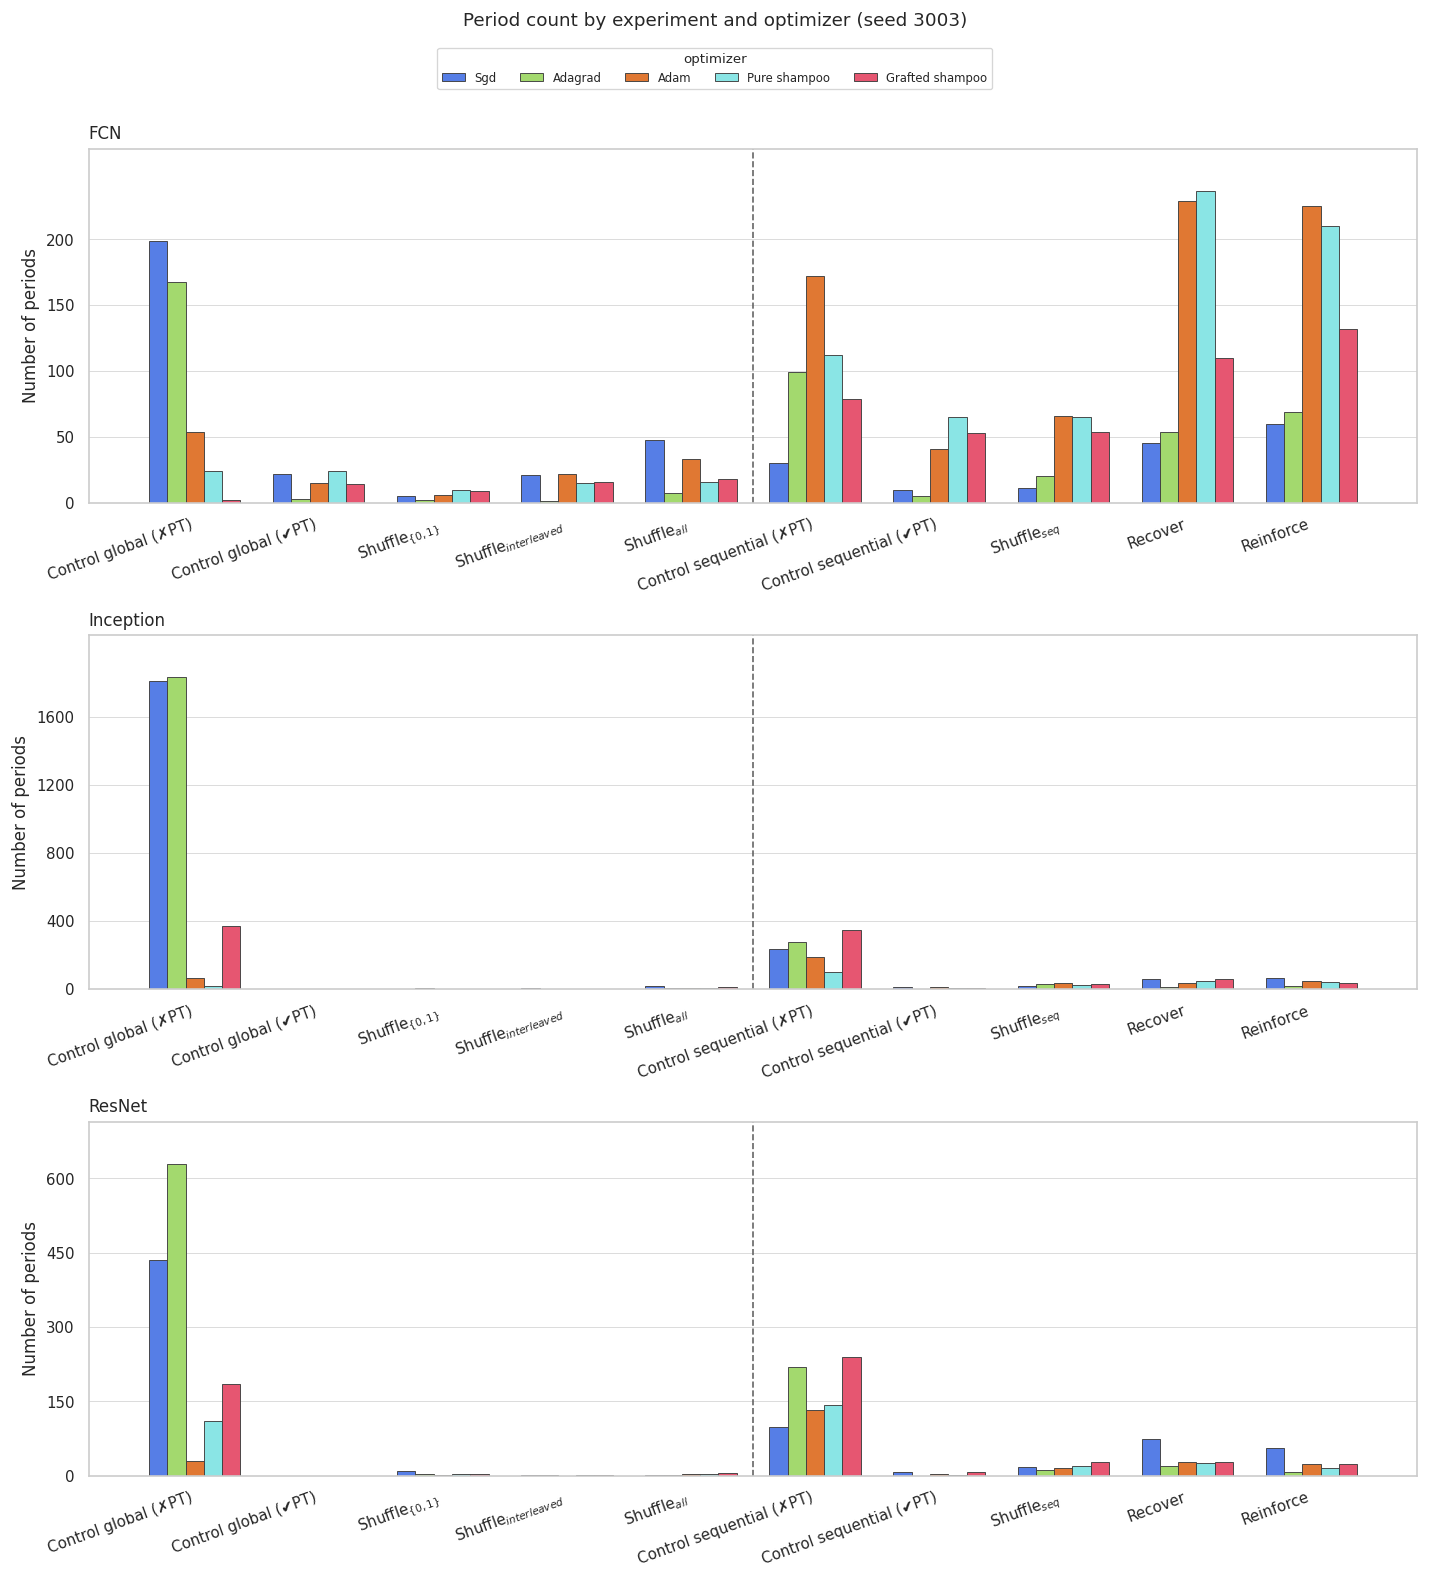

In [21]:
plot_report_period_count_figure(
	df_counts,
	all_results,
	labels=LABELS,
	sort_experiment_names=_sort_experiment_display_names,
	plot_dir=PLOT_DIR,
	filename="report_period_count.pdf",
	title="Period count by experiment and optimizer (seed 3003)",
)

## 2. Total score (BSS)


[Inception / Control sequential (✗PT)] 9 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=2.62e-04, Holm p=7.85e-04 (***)
  Sgd vs Adam: raw p=4.20e-27, Holm p=4.20e-26 (***)
  Sgd vs Pure shampoo: raw p=7.82e-27, Holm p=7.04e-26 (***)
  Sgd vs Grafted shampoo: raw p=9.20e-13, Holm p=5.52e-12 (***)
  Adagrad vs Adam: raw p=4.00e-15, Holm p=2.80e-14 (***)
  Adagrad vs Pure shampoo: raw p=6.01e-16, Holm p=4.81e-15 (***)
  Adagrad vs Grafted shampoo: raw p=4.37e-04, Holm p=8.73e-04 (***)
  Adam vs Grafted shampoo: raw p=1.62e-07, Holm p=6.46e-07 (***)
  Pure shampoo vs Grafted shampoo: raw p=8.02e-09, Holm p=4.01e-08 (***)
[Control sequential (✗PT)] 9 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=1.30e-03, Holm p=3.90e-03 (**)
  Sgd vs Adam: raw p=1.41e-17, Holm p=1.27e-16 (***)
  Sgd vs Pure shampoo: raw p=8.00e-18, Holm p=8.00e-17 (***)
  Sgd vs Grafted shampoo: raw p=3.10e-10, Holm p=1.86e-09 (***)
  Adagrad vs Adam: raw p=6.45e-11, Holm p=4.52e-10 (***)
  

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/style.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_total_score.pdf


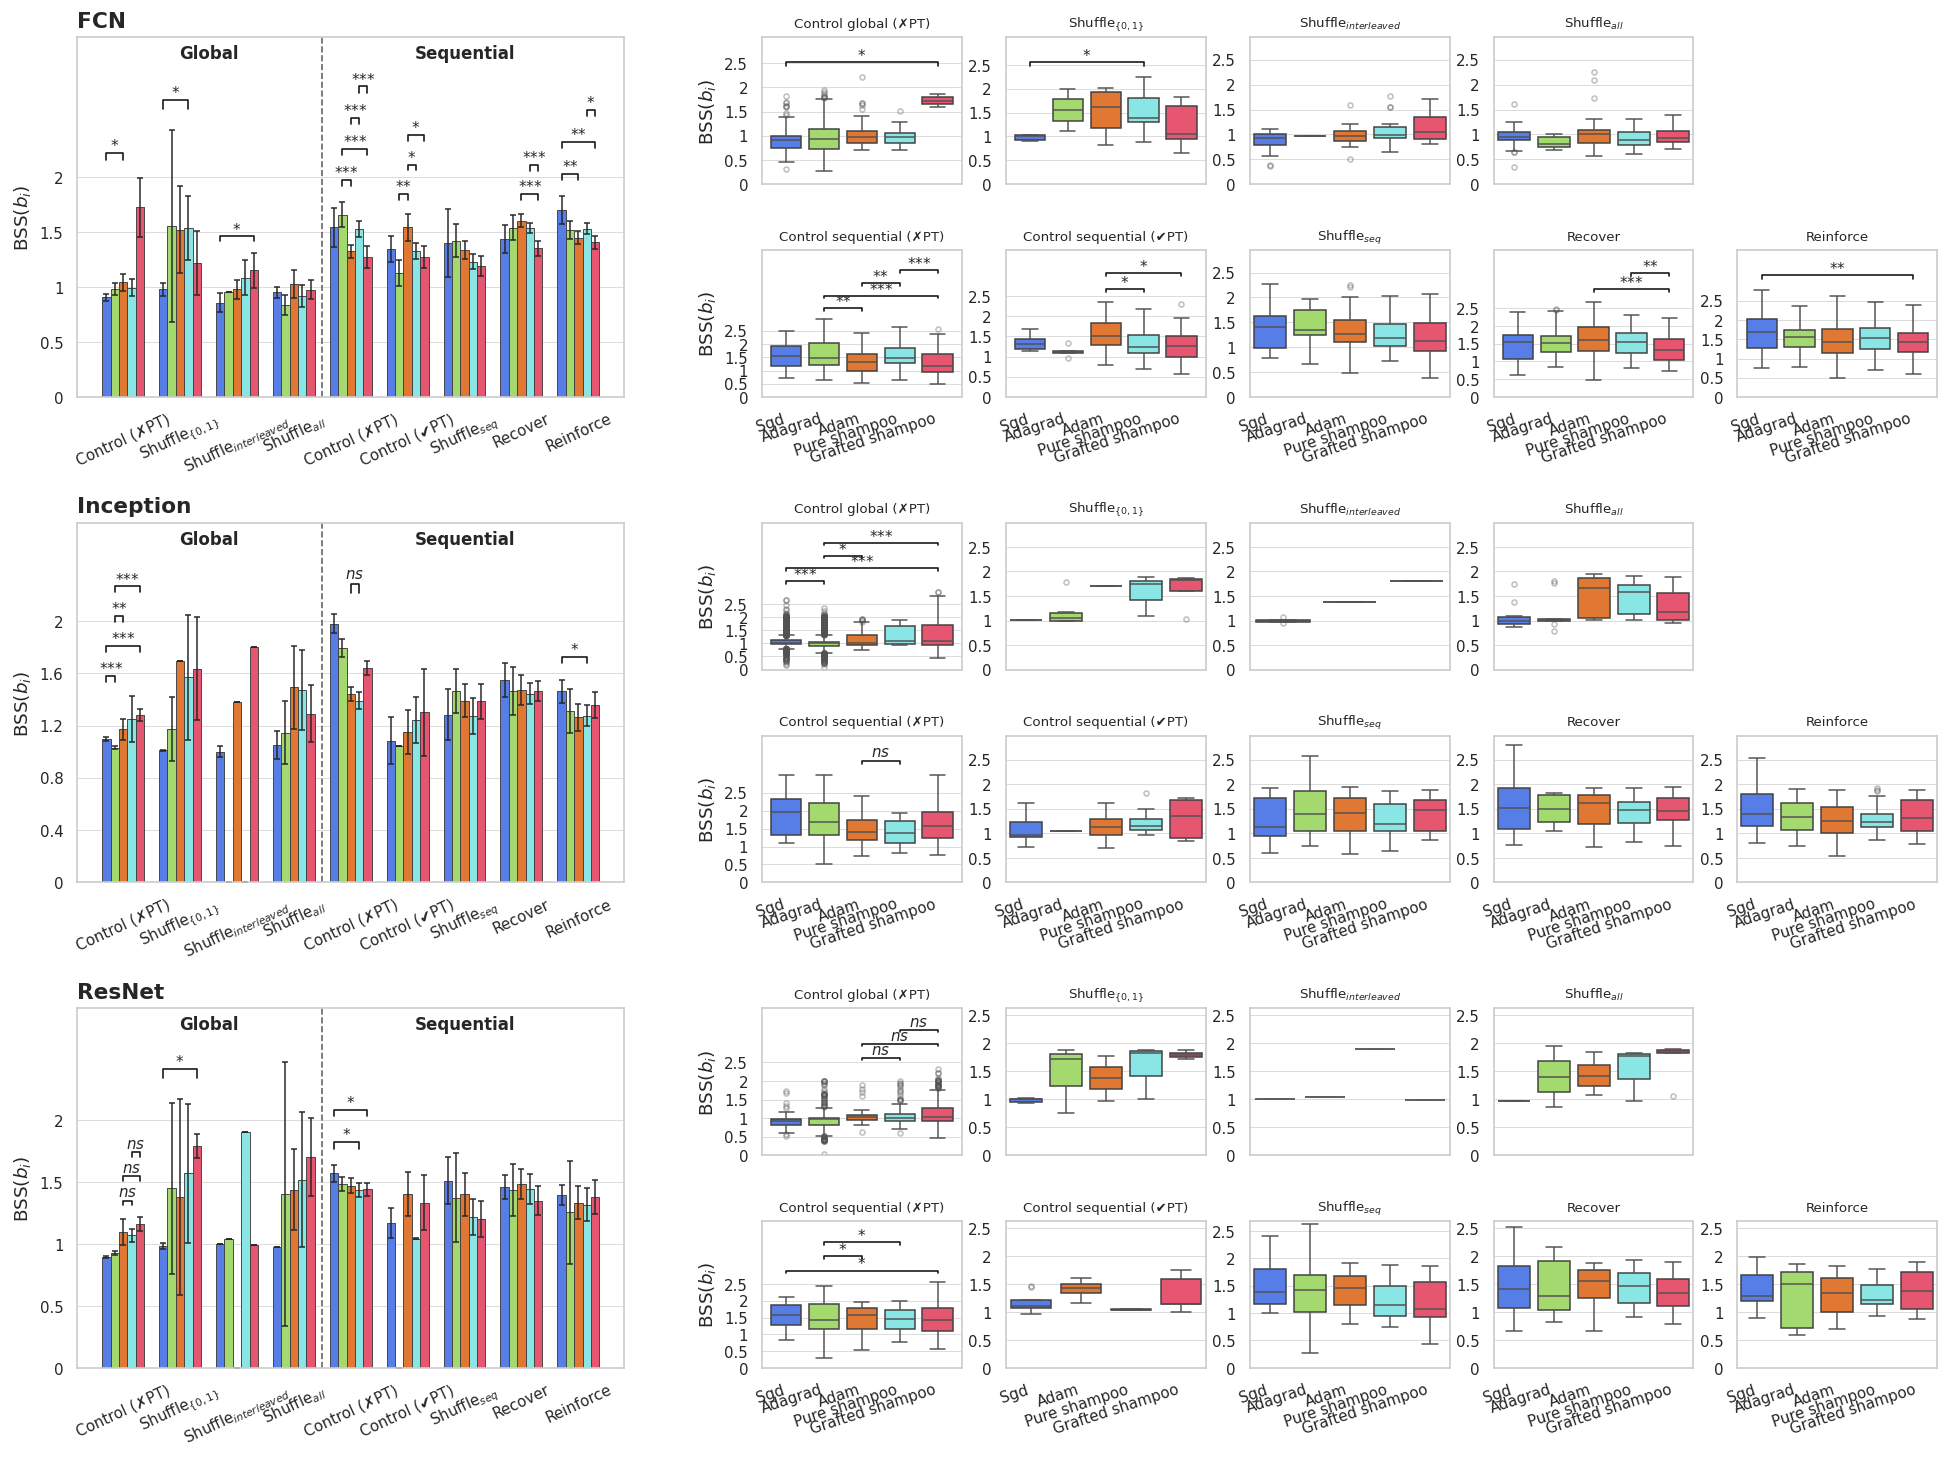

In [22]:
plot_report_metric_figure(
	df_long,
	all_results,
	metric="total_score",
	labels=LABELS,
	sort_experiment_names=_sort_experiment_display_names,
	plot_dir=PLOT_DIR,
	filename="report_total_score.pdf",
	title="Total BSS by experiment and optimizer",
	ylabel=r"$\operatorname{BSS}(b_i)$",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
)


## 3. Mean period length

[Control global (✗PT)] 8 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=6.11e-03, Holm p=2.44e-02 (*)
  Sgd vs Adam: raw p=1.42e-12, Holm p=1.28e-11 (***)
  Sgd vs Pure shampoo: raw p=2.01e-08, Holm p=1.41e-07 (***)
  Sgd vs Grafted shampoo: raw p=9.95e-05, Holm p=5.97e-04 (***)
  Adagrad vs Adam: raw p=1.84e-16, Holm p=1.84e-15 (***)
  Adagrad vs Pure shampoo: raw p=4.13e-12, Holm p=3.31e-11 (***)
  Adagrad vs Grafted shampoo: raw p=2.92e-03, Holm p=1.46e-02 (*)
  Adam vs Grafted shampoo: raw p=1.30e-02, Holm p=3.90e-02 (*)
[Control global (✗PT)] 10 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=2.48e-02, Holm p=2.48e-02 (*)
  Sgd vs Adam: raw p=2.62e-23, Holm p=1.84e-22 (***)
  Sgd vs Pure shampoo: raw p=4.34e-10, Holm p=2.17e-09 (***)
  Sgd vs Grafted shampoo: raw p=4.52e-61, Holm p=4.07e-60 (***)
  Adagrad vs Adam: raw p=1.38e-24, Holm p=1.11e-23 (***)
  Adagrad vs Pure shampoo: raw p=1.61e-10, Holm p=9.64e-10 (***)
  Adagrad vs Grafted shampoo: raw p=

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/style.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_period_length.pdf


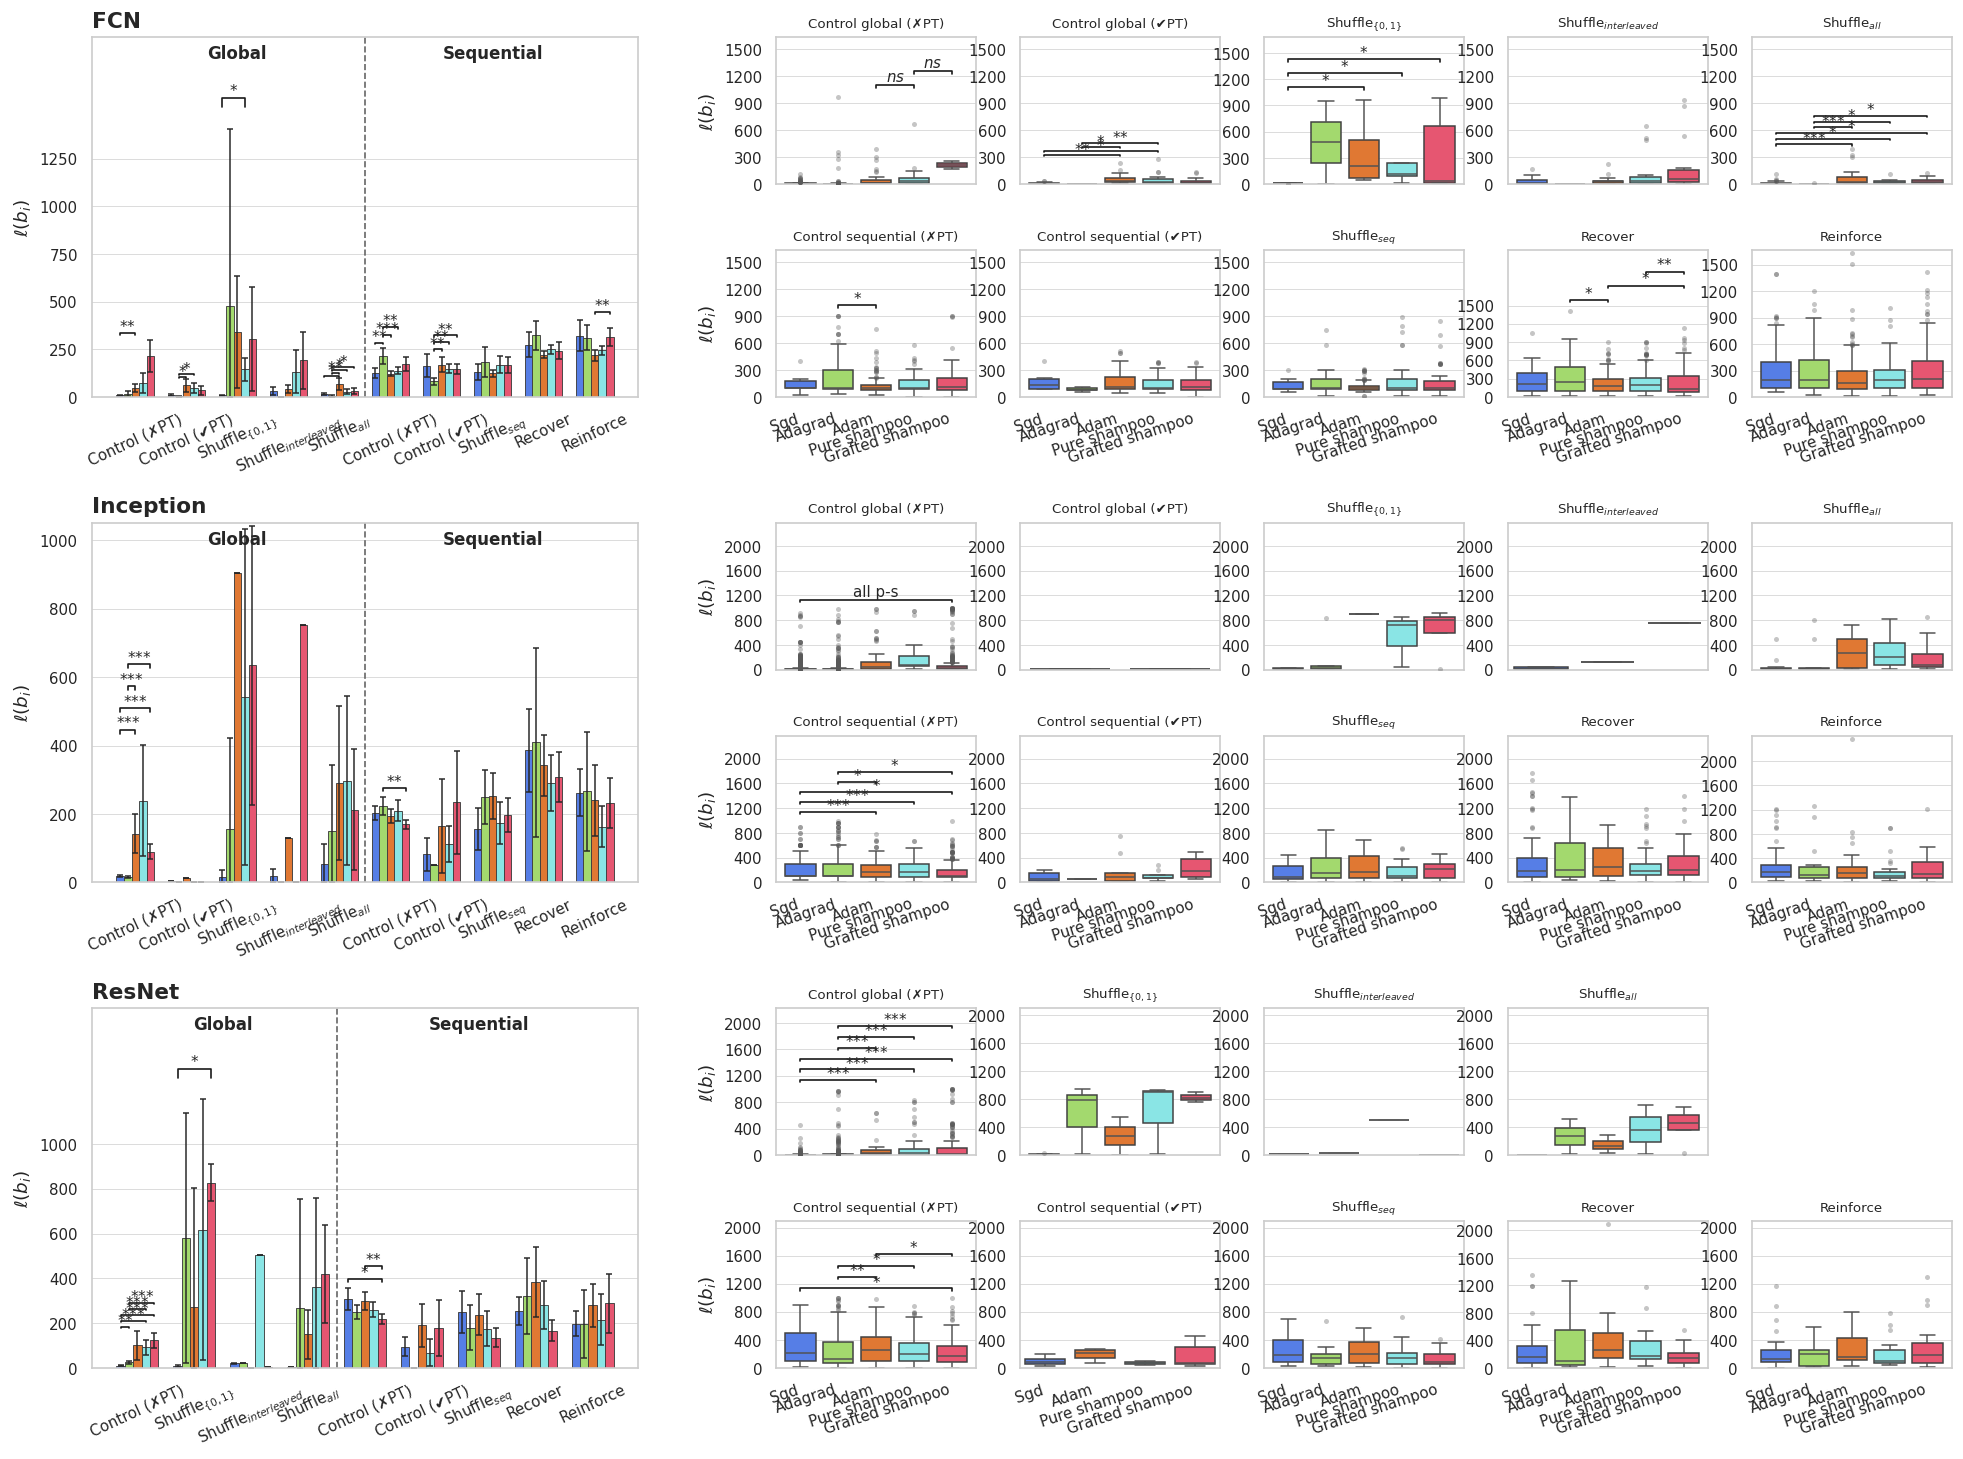

In [23]:
plot_report_metric_figure(
	df_long,
	all_results,
	metric="total_length_iter",
	labels=LABELS,
	sort_experiment_names=_sort_experiment_display_names,
	plot_dir=PLOT_DIR,
	filename="report_period_length.pdf",
	title="Period length by experiment and optimizer",
	ylabel=r"$\ell(b_i)$",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
	use_length_outliers=True,
)

## 4. Activation angle

[FCN / Reinforce] 7 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=2.57e-04, Holm p=1.54e-03 (**)
  Sgd vs Adam: raw p=1.57e-03, Holm p=7.84e-03 (**)
  Sgd vs Pure shampoo: raw p=1.73e-04, Holm p=1.21e-03 (**)
  Sgd vs Grafted shampoo: raw p=5.03e-05, Holm p=4.02e-04 (***)
  Adam vs Pure shampoo: raw p=9.03e-07, Holm p=8.12e-06 (***)
  Adam vs Grafted shampoo: raw p=1.18e-10, Holm p=1.18e-09 (***)
  Pure shampoo vs Grafted shampoo: raw p=8.58e-03, Holm p=3.43e-02 (*)
[Control sequential (✗PT)] 9 significant pair(s) (Holm corrected):
  Sgd vs Adam: raw p=2.09e-03, Holm p=1.25e-02 (*)
  Sgd vs Pure shampoo: raw p=1.27e-02, Holm p=2.55e-02 (*)
  Sgd vs Grafted shampoo: raw p=3.29e-03, Holm p=1.65e-02 (*)
  Adagrad vs Adam: raw p=7.83e-03, Holm p=2.35e-02 (*)
  Adagrad vs Pure shampoo: raw p=2.11e-04, Holm p=1.69e-03 (**)
  Adagrad vs Grafted shampoo: raw p=2.95e-04, Holm p=2.06e-03 (**)
  Adam vs Pure shampoo: raw p=4.80e-03, Holm p=1.92e-02 (*)
  Adam vs Grafted shampoo: r

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/style.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_activation_angle.pdf


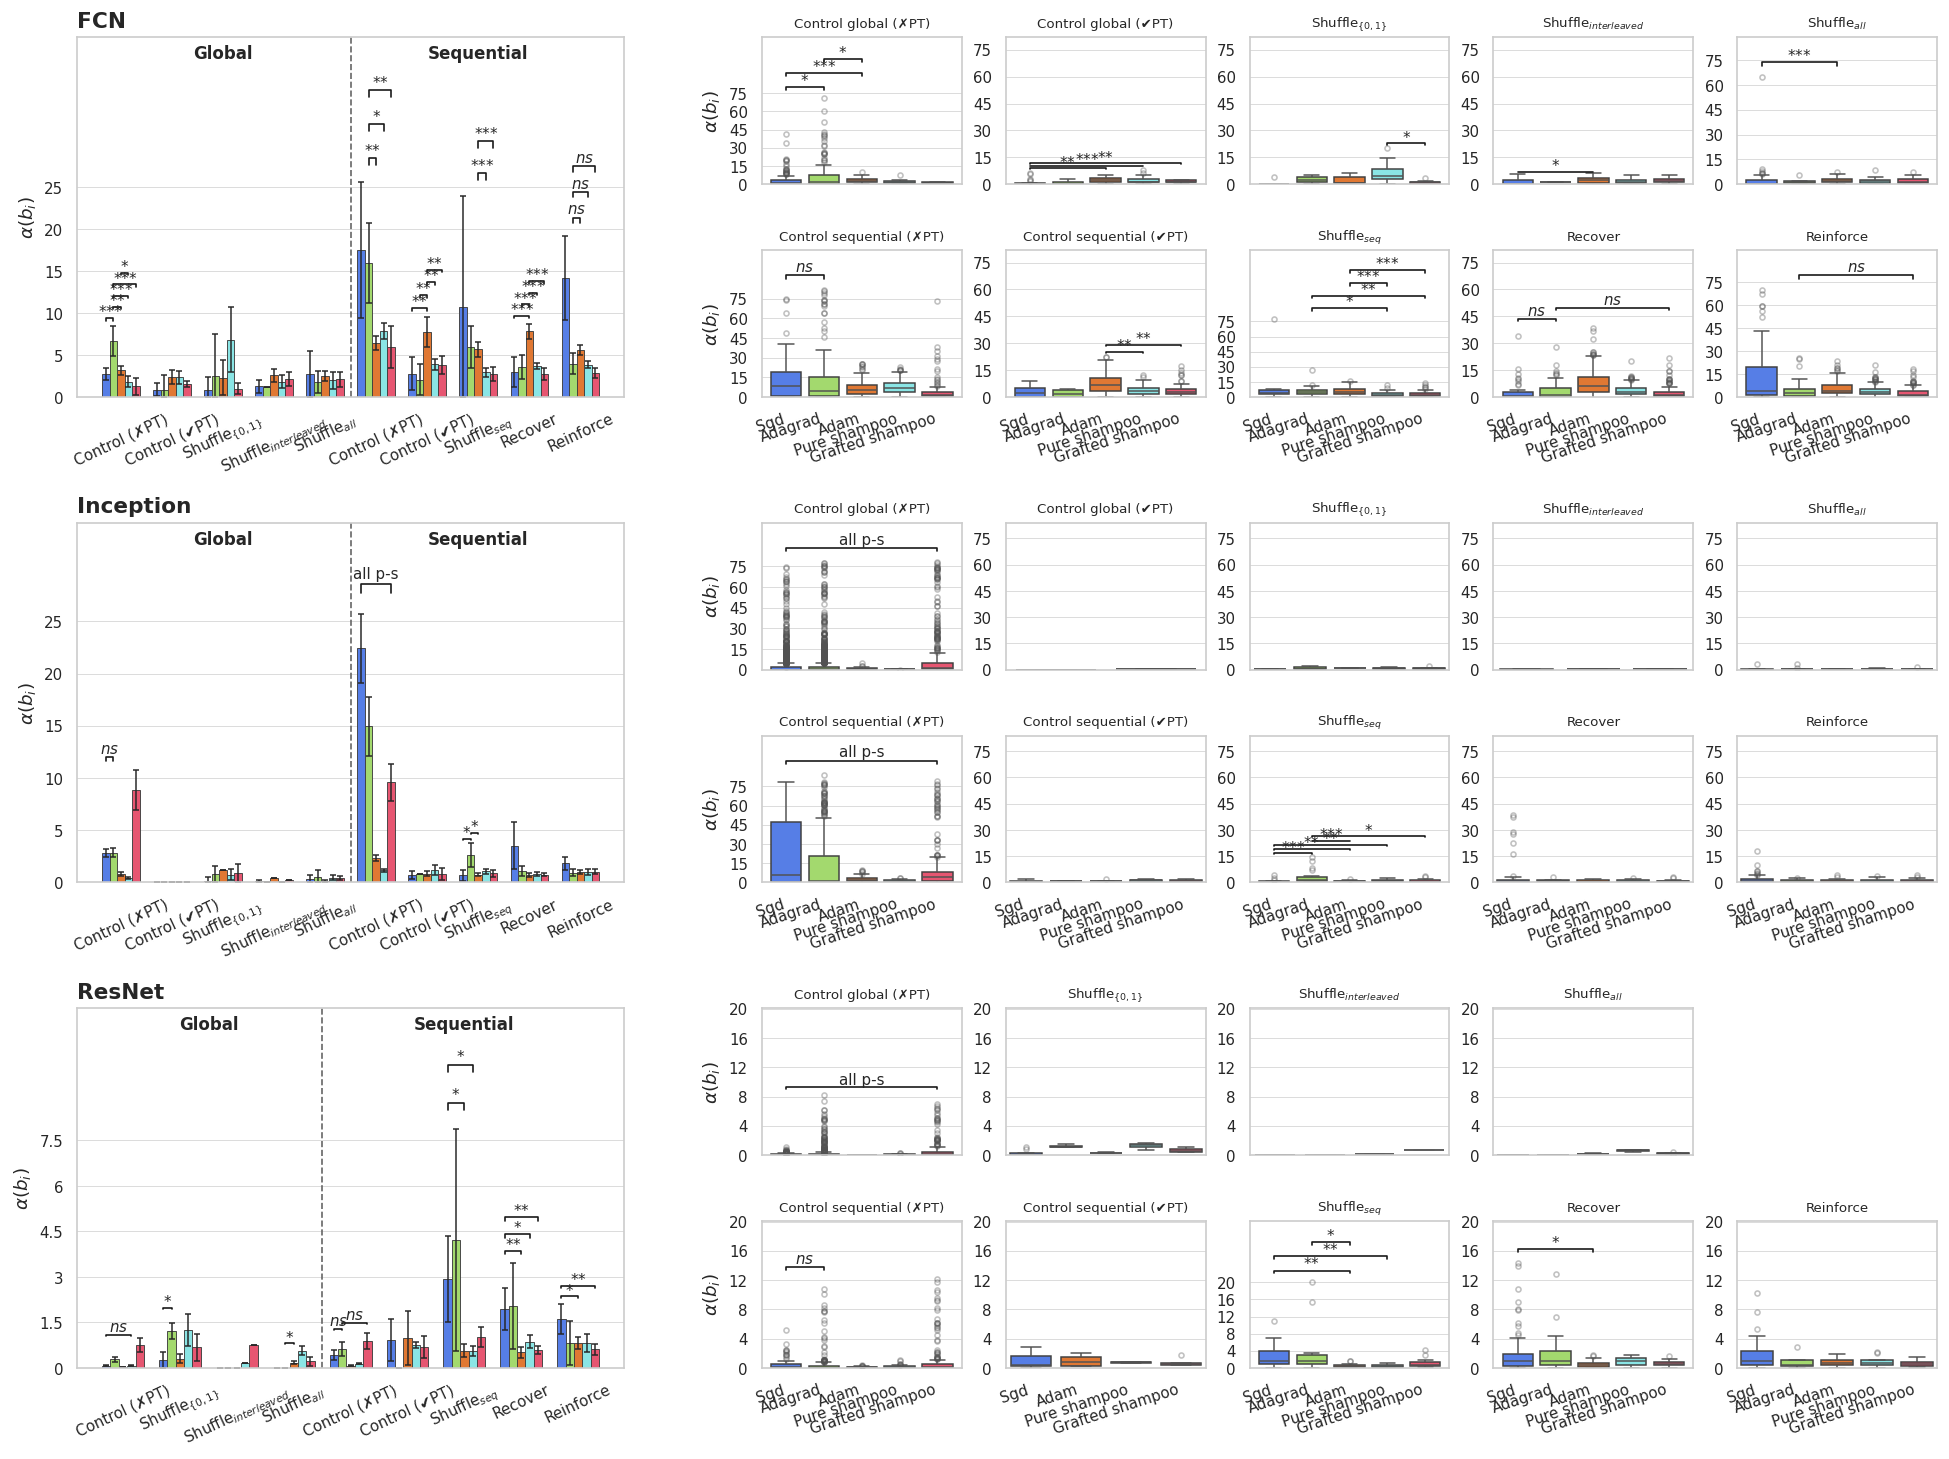

In [24]:
plot_report_metric_figure(
	df_long,
	all_results,
	metric="activation_angle",
	labels=LABELS,
	sort_experiment_names=_sort_experiment_display_names,
	plot_dir=PLOT_DIR,
	filename="report_activation_angle.pdf",
	title="Activation angle by experiment and optimizer",
	ylabel=r"$\alpha(b_i)$",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
)

## 4. Robustness (min-max normalized)

Per-model min-max of raw robustness score ($1 - \sigma$), from `minmax_normalized_robustness_scores` in cached analysis (see `scripts/slurm/min_max_individual.py`).

/home/garvalov/thesis/plateau_optimizer/network_analyzer/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/garvalov/thesis/plateau_optimizer/network_analyzer/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/garvalov/thesis/plateau_optimizer/network_analyzer/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypote

[Inception / Control sequential (✗PT)] 9 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=1.78e-02, Holm p=3.57e-02 (*)
  Sgd vs Adam: raw p=7.43e-45, Holm p=7.43e-44 (***)
  Sgd vs Pure shampoo: raw p=1.05e-31, Holm p=8.42e-31 (***)
  Sgd vs Grafted shampoo: raw p=5.33e-22, Holm p=3.20e-21 (***)
  Adagrad vs Adam: raw p=4.07e-38, Holm p=3.66e-37 (***)
  Adagrad vs Pure shampoo: raw p=1.79e-28, Holm p=1.25e-27 (***)
  Adagrad vs Grafted shampoo: raw p=7.74e-16, Holm p=3.87e-15 (***)
  Adam vs Grafted shampoo: raw p=5.55e-06, Holm p=1.67e-05 (***)
  Pure shampoo vs Grafted shampoo: raw p=3.32e-06, Holm p=1.33e-05 (***)
[Control global (✗PT)] 9 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=4.53e-55, Holm p=4.53e-54 (***)
  Sgd vs Adam: raw p=1.62e-20, Holm p=1.29e-19 (***)
  Sgd vs Pure shampoo: raw p=2.16e-08, Holm p=1.51e-07 (***)
  Sgd vs Grafted shampoo: raw p=4.90e-29, Holm p=4.41e-28 (***)
  Adagrad vs Adam: raw p=1.72e-07, Holm p=1.03e-06 (***)
  Adagr

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/style.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_robustness_score.pdf


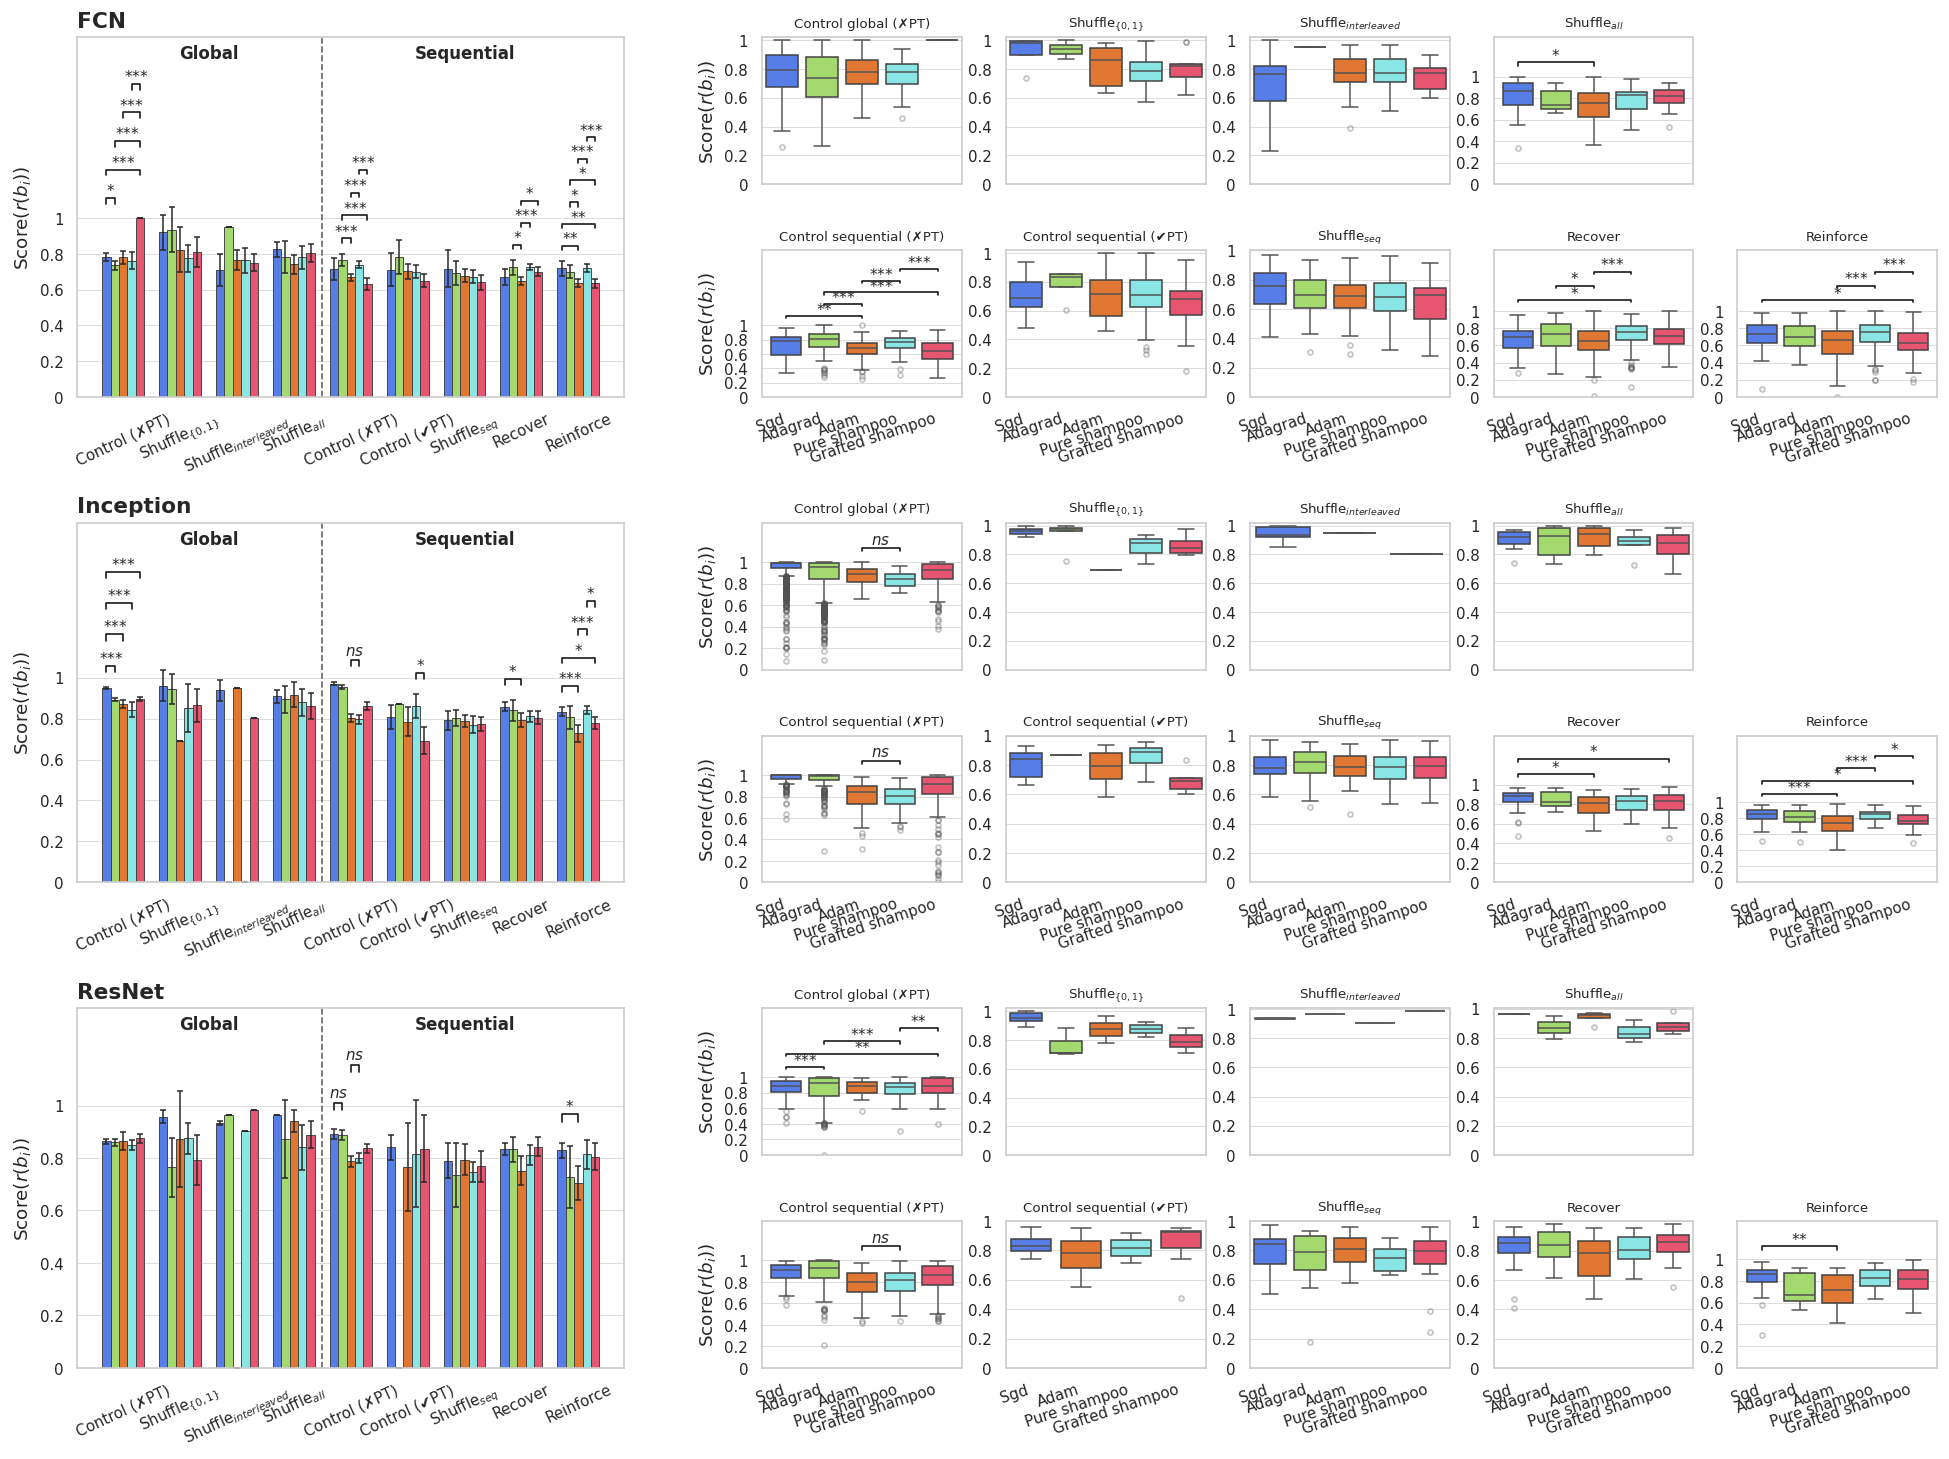

In [25]:
_rob_metric = robustness_long_metric_name(df_long)
plot_report_metric_figure(
	df_long,
	all_results,
	metric=_rob_metric,
	labels=LABELS,
	sort_experiment_names=_sort_experiment_display_names,
	plot_dir=PLOT_DIR,
	filename="report_robustness_score.pdf",
	title="Robustness (min-max normalized) by experiment and optimizer",
	ylabel=r"$\mathrm{Score}(r(b_i))$",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
)

## 6. $t_\mathrm{start}$

[Inception / Control global (✗PT)] 9 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=4.04e-15, Holm p=4.04e-14 (***)
  Sgd vs Adam: raw p=3.78e-03, Holm p=1.13e-02 (*)
  Sgd vs Pure shampoo: raw p=3.40e-04, Holm p=1.36e-03 (**)
  Sgd vs Grafted shampoo: raw p=2.39e-08, Holm p=2.15e-07 (***)
  Adagrad vs Adam: raw p=1.05e-05, Holm p=7.38e-05 (***)
  Adagrad vs Pure shampoo: raw p=4.50e-05, Holm p=2.25e-04 (***)
  Adam vs Pure shampoo: raw p=2.12e-02, Holm p=4.25e-02 (*)
  Adam vs Grafted shampoo: raw p=2.78e-06, Holm p=2.23e-05 (***)
  Pure shampoo vs Grafted shampoo: raw p=2.27e-05, Holm p=1.36e-04 (***)
[Inception / Control sequential (✗PT)] 7 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=5.12e-06, Holm p=3.58e-05 (***)
  Sgd vs Adam: raw p=8.81e-16, Holm p=7.93e-15 (***)
  Sgd vs Pure shampoo: raw p=1.66e-12, Holm p=1.33e-11 (***)
  Sgd vs Grafted shampoo: raw p=1.58e-28, Holm p=1.58e-27 (***)
  Adagrad vs Pure shampoo: raw p=7.53e-03, Holm p=3.77e-02 (*

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/style.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_t_start.pdf


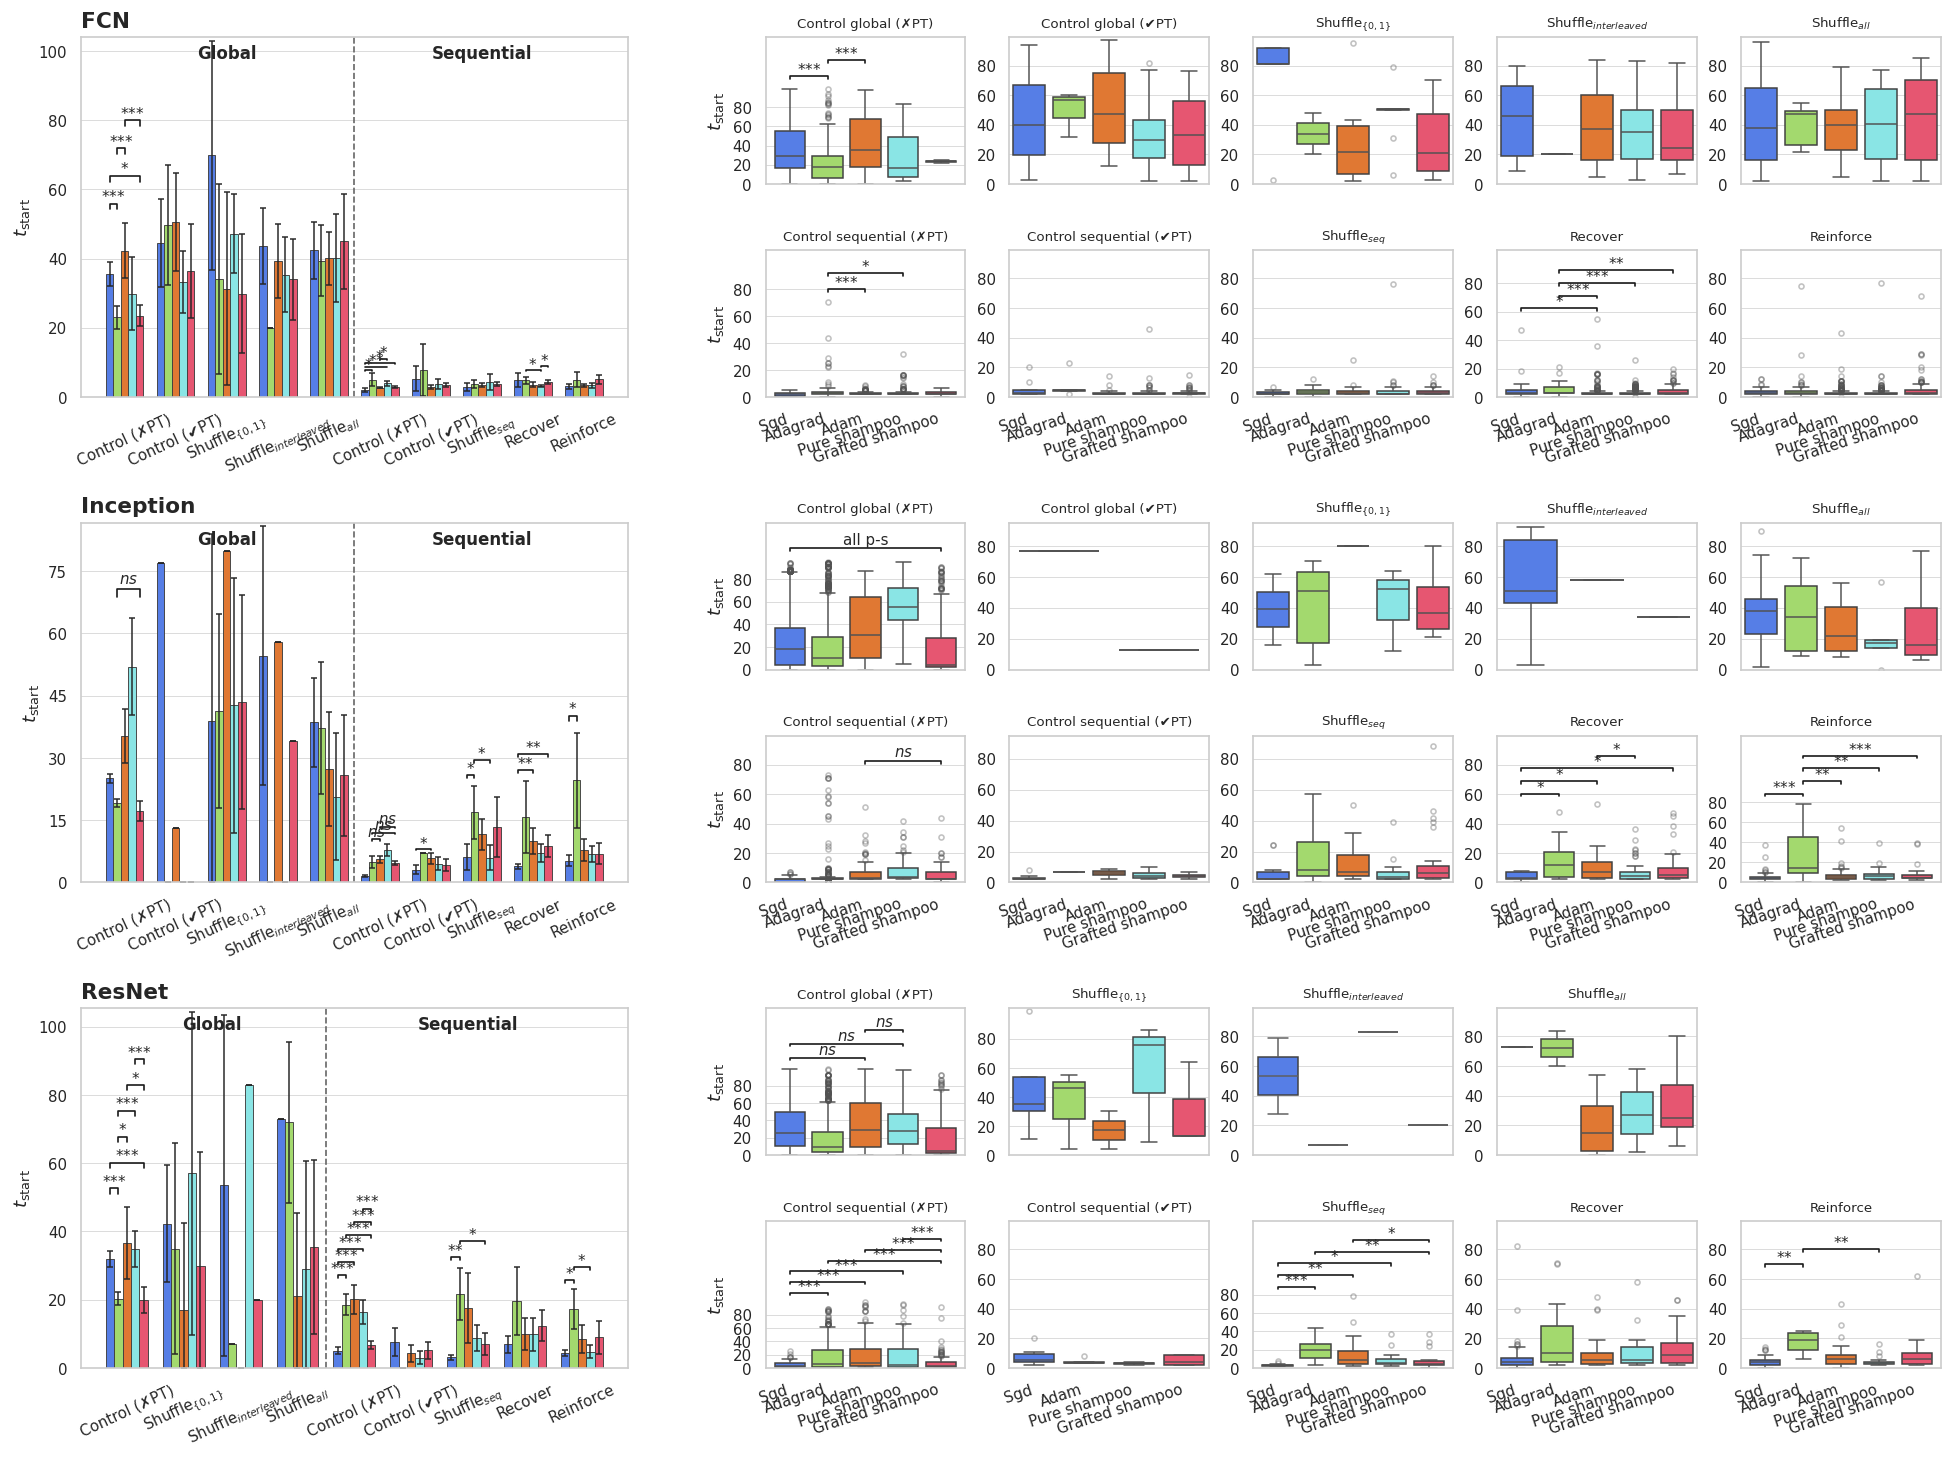

In [26]:
plot_report_metric_figure(
	df_long,
	all_results,
	metric="point_of_max_acceleration",
	labels=LABELS,
	sort_experiment_names=_sort_experiment_display_names,
	plot_dir=PLOT_DIR,
	filename="report_t_start.pdf",
	title=r"$t_{\mathrm{start}}$ by experiment and optimizer",
	ylabel=r"$t_{\mathrm{start}}$",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
)

## 6. Loss peak magnitude

Per detected training-loss peak: loss at peak / mean training loss (one sample per peak).

[FCN / Control sequential (✗PT)] 8 significant pair(s) (Holm corrected):
  Sgd vs Adam: raw p=2.17e-03, Holm p=1.30e-02 (*)
  Sgd vs Pure shampoo: raw p=7.41e-03, Holm p=2.97e-02 (*)
  Sgd vs Grafted shampoo: raw p=1.72e-03, Holm p=1.20e-02 (*)
  Adagrad vs Adam: raw p=3.13e-04, Holm p=2.82e-03 (**)
  Adagrad vs Pure shampoo: raw p=1.08e-03, Holm p=8.64e-03 (**)
  Adagrad vs Grafted shampoo: raw p=2.50e-04, Holm p=2.50e-03 (**)
  Adam vs Pure shampoo: raw p=9.19e-03, Holm p=2.97e-02 (*)
  Pure shampoo vs Grafted shampoo: raw p=2.30e-03, Holm p=1.30e-02 (*)
[FCN / Recover] 7 significant pair(s) (Holm corrected):
  Sgd vs Adagrad: raw p=7.30e-03, Holm p=3.65e-02 (*)
  Sgd vs Adam: raw p=1.45e-03, Holm p=8.67e-03 (**)
  Sgd vs Pure shampoo: raw p=8.12e-03, Holm p=3.65e-02 (*)
  Sgd vs Grafted shampoo: raw p=2.66e-05, Holm p=2.13e-04 (***)
  Adagrad vs Grafted shampoo: raw p=9.81e-06, Holm p=8.83e-05 (***)
  Adam vs Grafted shampoo: raw p=9.23e-05, Holm p=6.46e-04 (***)
  Pure shampoo vs G

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/style.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_peak_magnitude.pdf


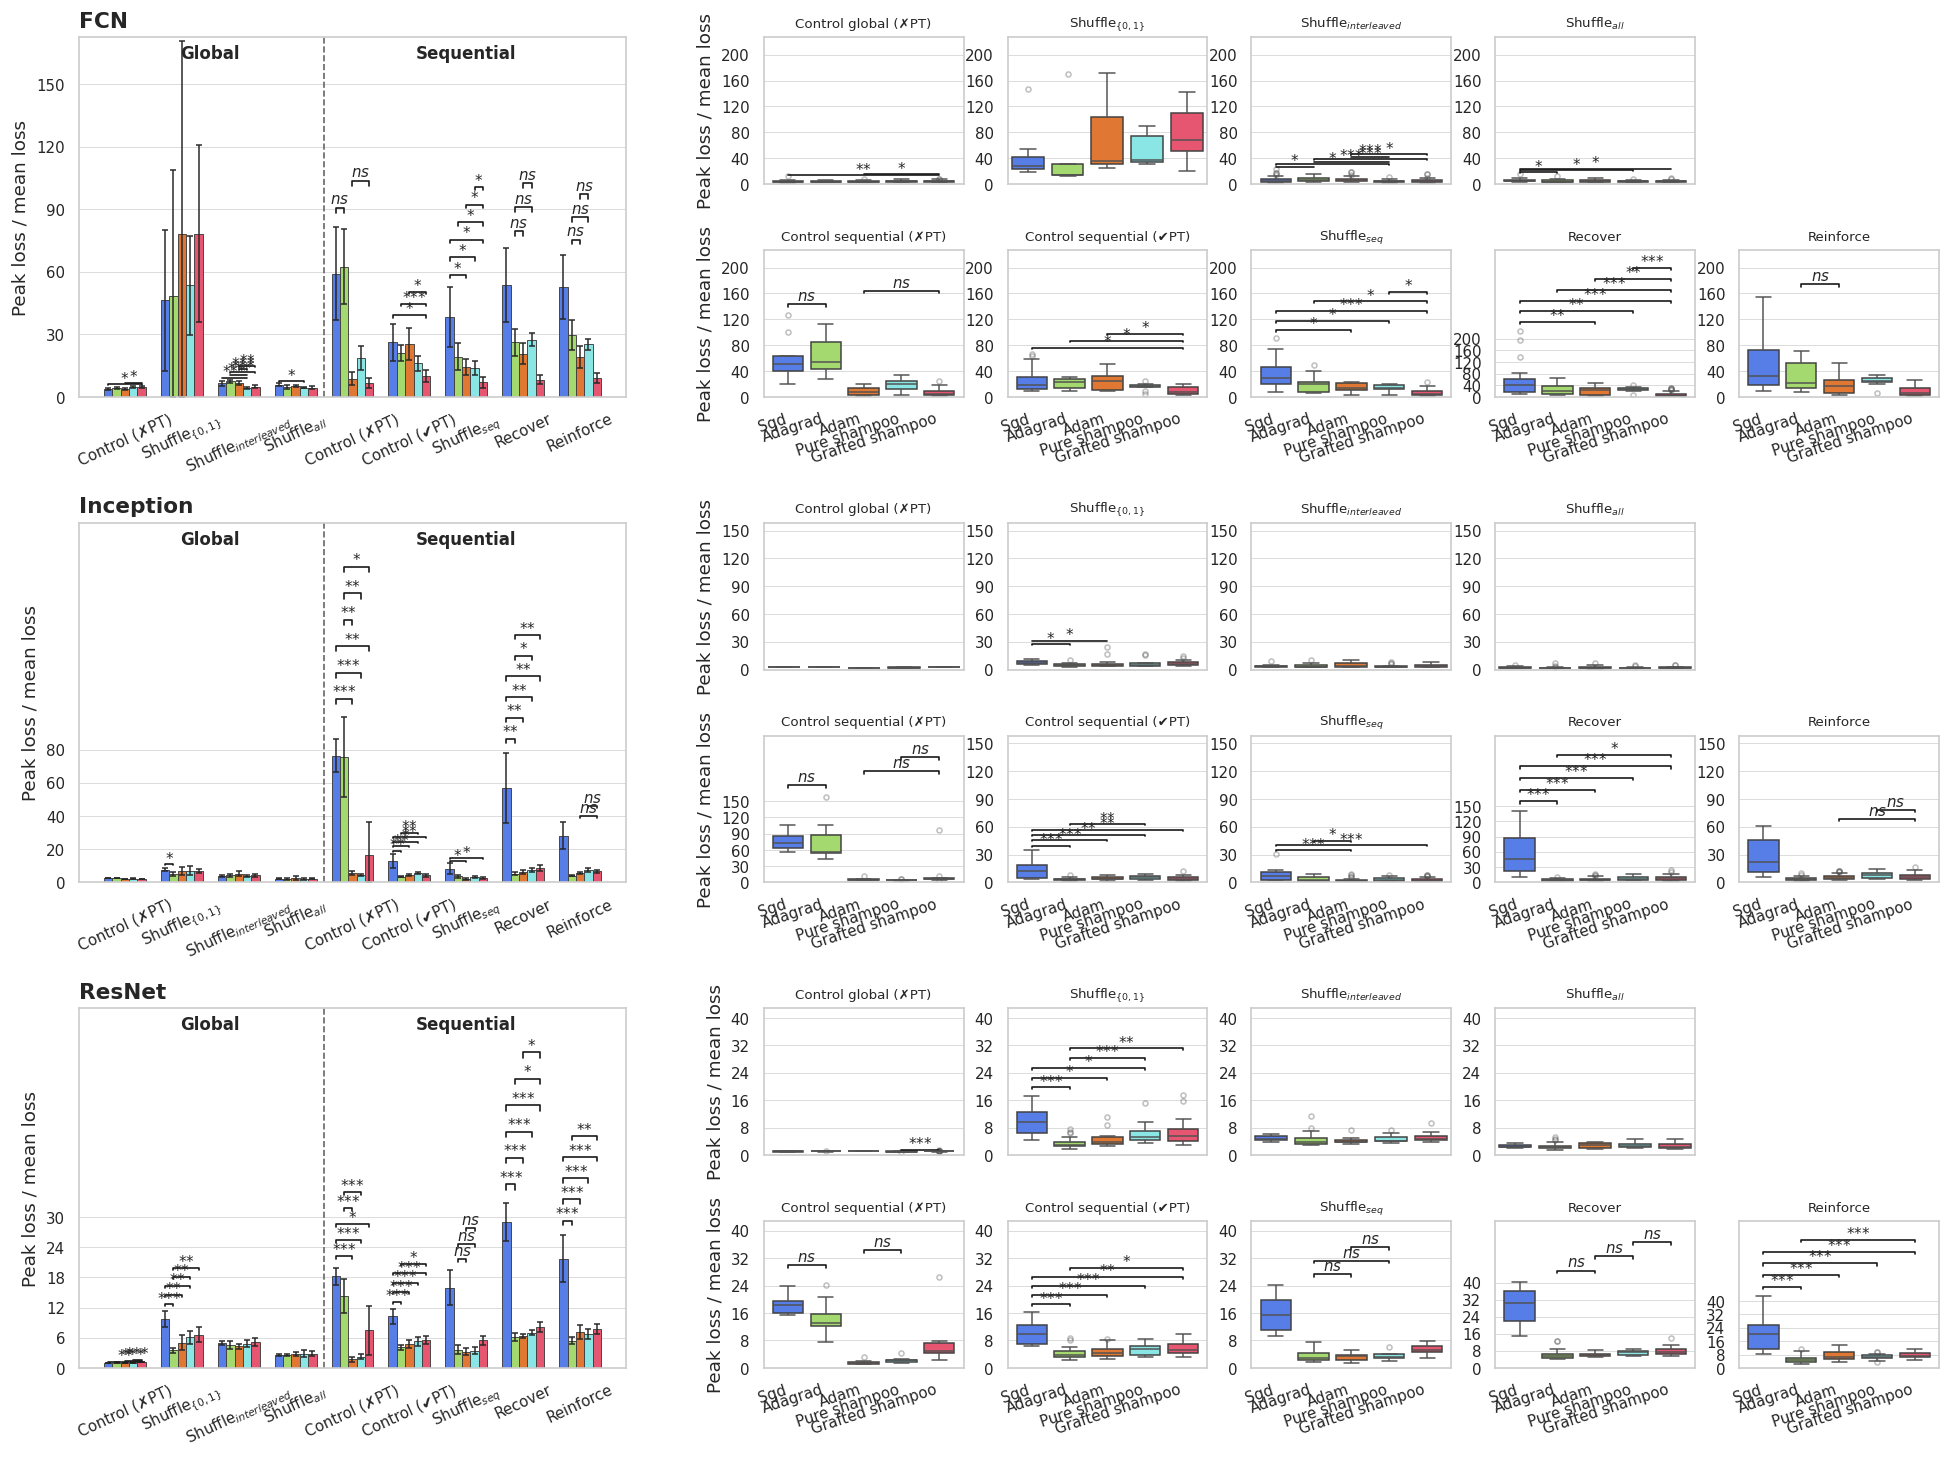

In [27]:
plot_report_metric_figure(
	df_peak,
	all_results,
	metric="peak_ratio",
	labels=LABELS,
	sort_experiment_names=_sort_experiment_display_names,
	plot_dir=PLOT_DIR,
	filename="report_peak_magnitude.pdf",
	title="Loss peak magnitude by experiment and optimizer",
	ylabel=r"Peak loss / mean loss",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
)

## 7. Time to convergence (TTC)

Cat1: $\mathrm{TTC}_{\mathrm{first,most}}$; Cat2: $\mathrm{TTC}_{\mathrm{each,most}}$ (iterations after peak until binned mean loss falls below late-phase threshold).

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/style.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_ttc.pdf


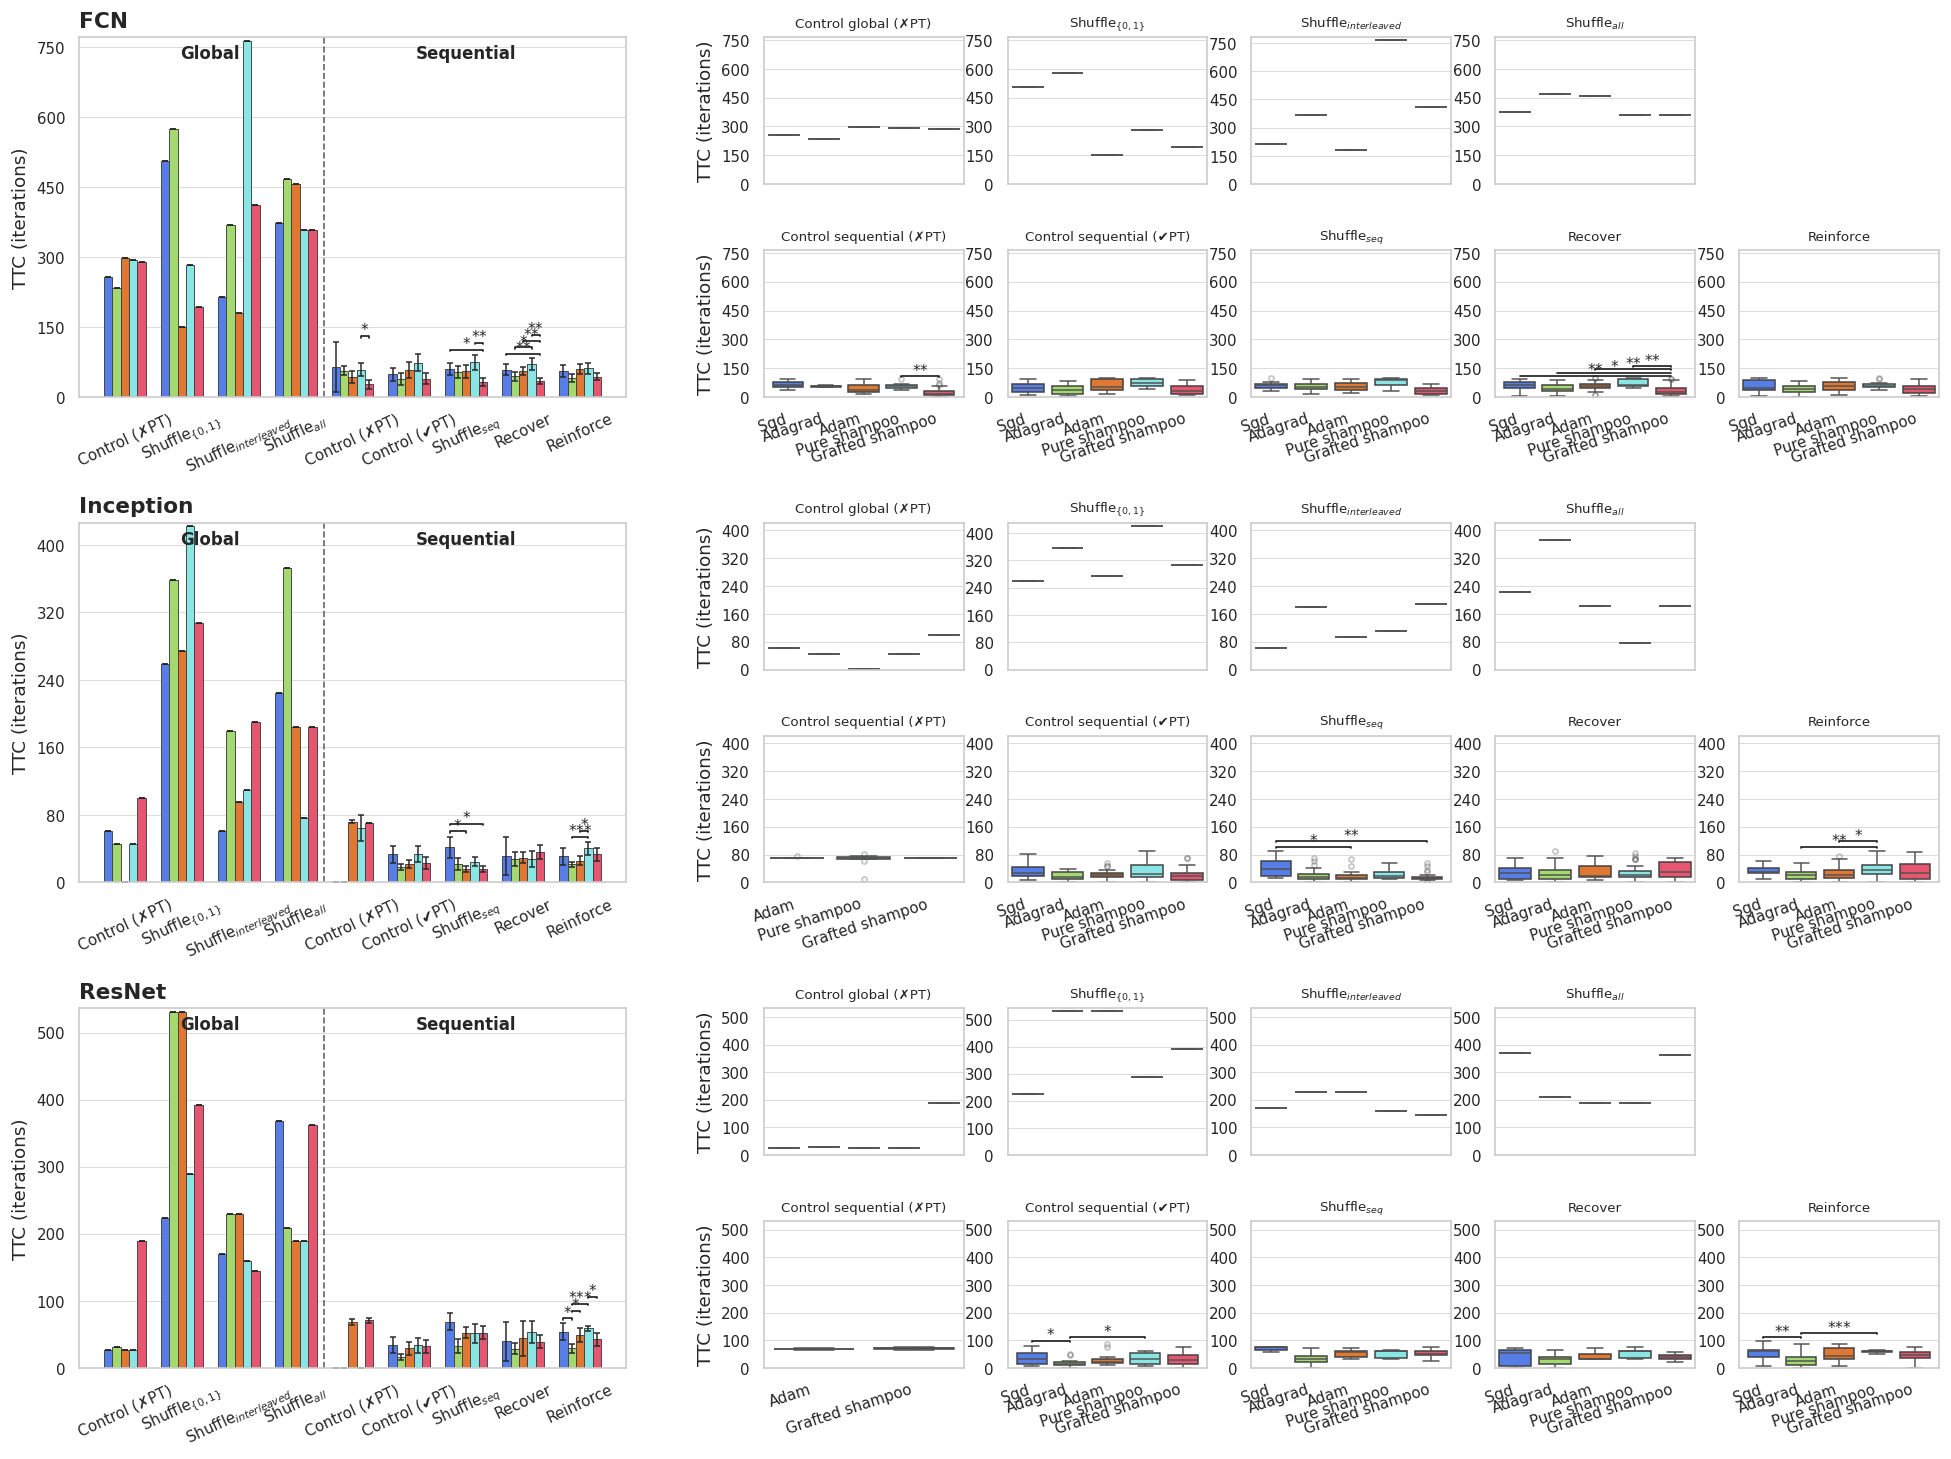

In [28]:
plot_report_metric_figure(
	df_ttc,
	all_results,
	metric="ttc",
	labels=LABELS,
	sort_experiment_names=_sort_experiment_display_names,
	plot_dir=PLOT_DIR,
	filename="report_ttc.pdf",
	title=r"TTC by experiment and optimizer (Cat1: $first,most$; Cat2: $each,most$)",
	ylabel="TTC (iterations)",
	show_significance=SHOW_SIGNIFICANCE,
	show_insignificance=SHOW_INSIGNIFICANCE,
)

## 9. Spider profiles

One figure per model; top row = Cat1, bottom row = Cat2. Each panel is one experiment; each optimizer is a spider polygon. **Larger radius = better** on every spoke.

Axes (clockwise): length score, angle score (optional via `show_angle`), robustness, $t_\mathrm{start}$, TTC (Cat1: `first,most`; Cat2: `each,most`).

Scoring: `length_score` and `angle_score` — pass-through; robustness — pipeline min-max when available, stretched onto radial rings 0.25→0.75, 0.5→0.8125, 0.75→0.875, 1→1 (labels on that spoke); $t_\mathrm{start}$ — linear score $\mathrm{clip}(1 - x/100,\ 0,\ 1)$; TTC — Cat1 hi=1000, Cat2 hi=100. Polygons show the mean score at each (optimizer, experiment).

In [29]:
spider_means = build_report_spider_means(df_long, df_ttc)
print(f"spider_means rows={len(spider_means)}")
display(spider_means.head(12))

spider_means rows=675


,model_id,experiment,optimizer_id,variable,value_norm
0,dnn_5x64,"$\text{Shuffle}_{\{0,1\}}$",adagrad,angle,0.117830
1,dnn_5x64,"$\text{Shuffle}_{\{0,1\}}$",adagrad,length,0.501667
2,dnn_5x64,"$\text{Shuffle}_{\{0,1\}}$",adagrad,robustness,0.936024
3,dnn_5x64,"$\text{Shuffle}_{\{0,1\}}$",adagrad,start_onset,0.660000
4,dnn_5x64,"$\text{Shuffle}_{\{0,1\}}$",adagrad,ttc,0.424000
5,dnn_5x64,"$\text{Shuffle}_{\{0,1\}}$",adam,angle,0.089046
6,dnn_5x64,"$\text{Shuffle}_{\{0,1\}}$",adam,length,0.611667
7,dnn_5x64,"$\text{Shuffle}_{\{0,1\}}$",adam,robustness,0.823277
8,dnn_5x64,"$\text{Shuffle}_{\{0,1\}}$",adam,start_onset,0.686667
9,dnn_5x64,"$\text{Shuffle}_{\{0,1\}}$",adam,ttc,0.850000


/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/spider_profiles.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_spider.pdf


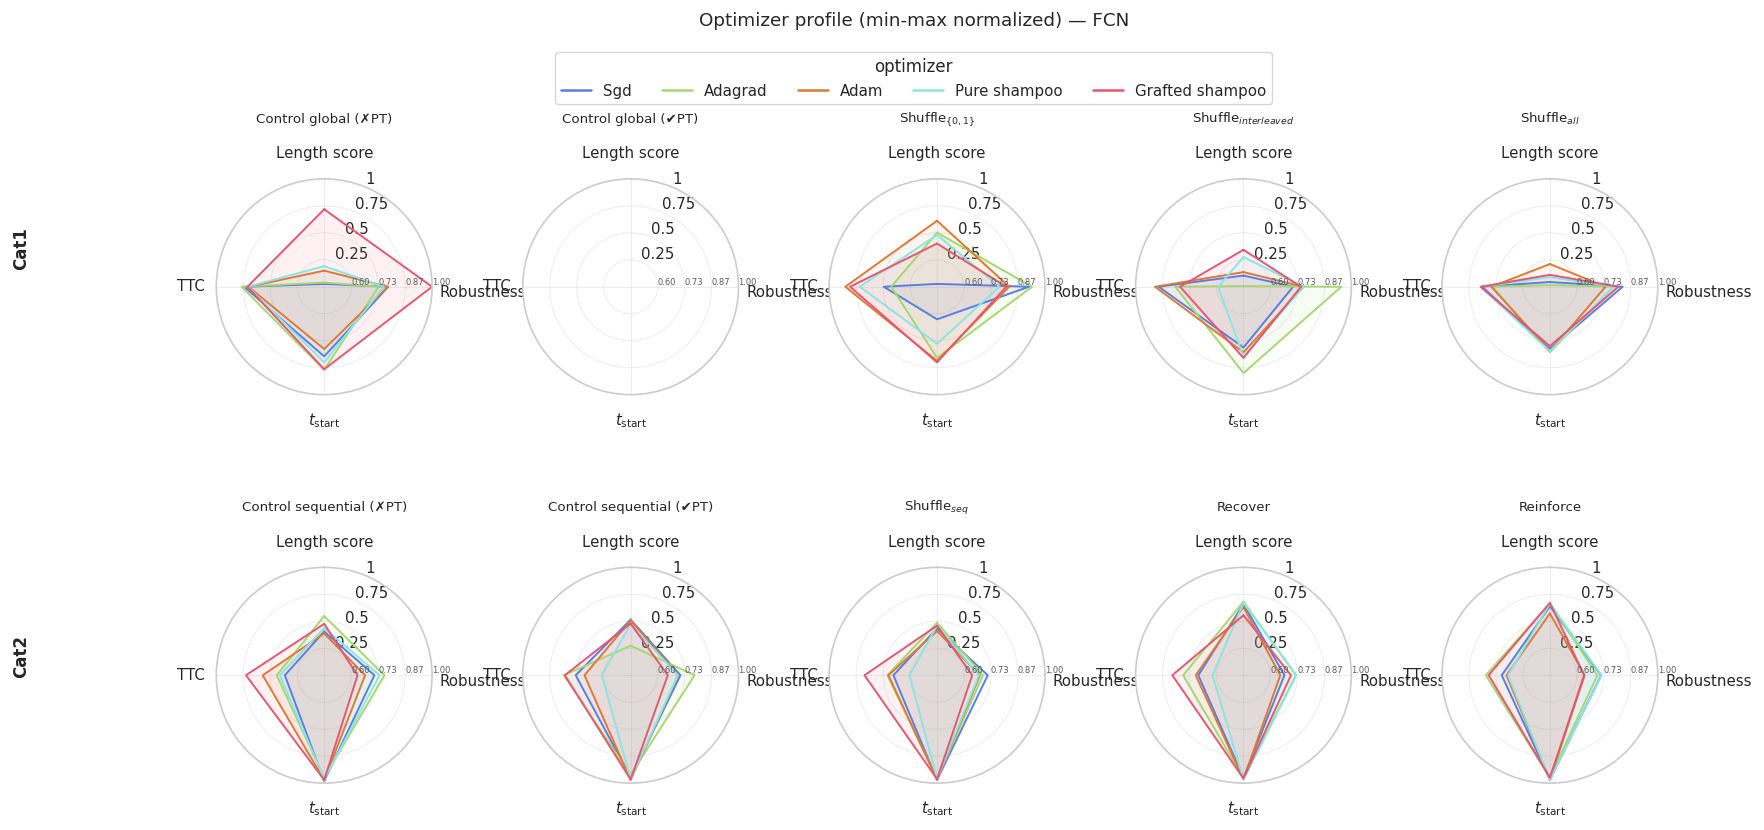

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/spider_profiles.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_spider_inception.pdf


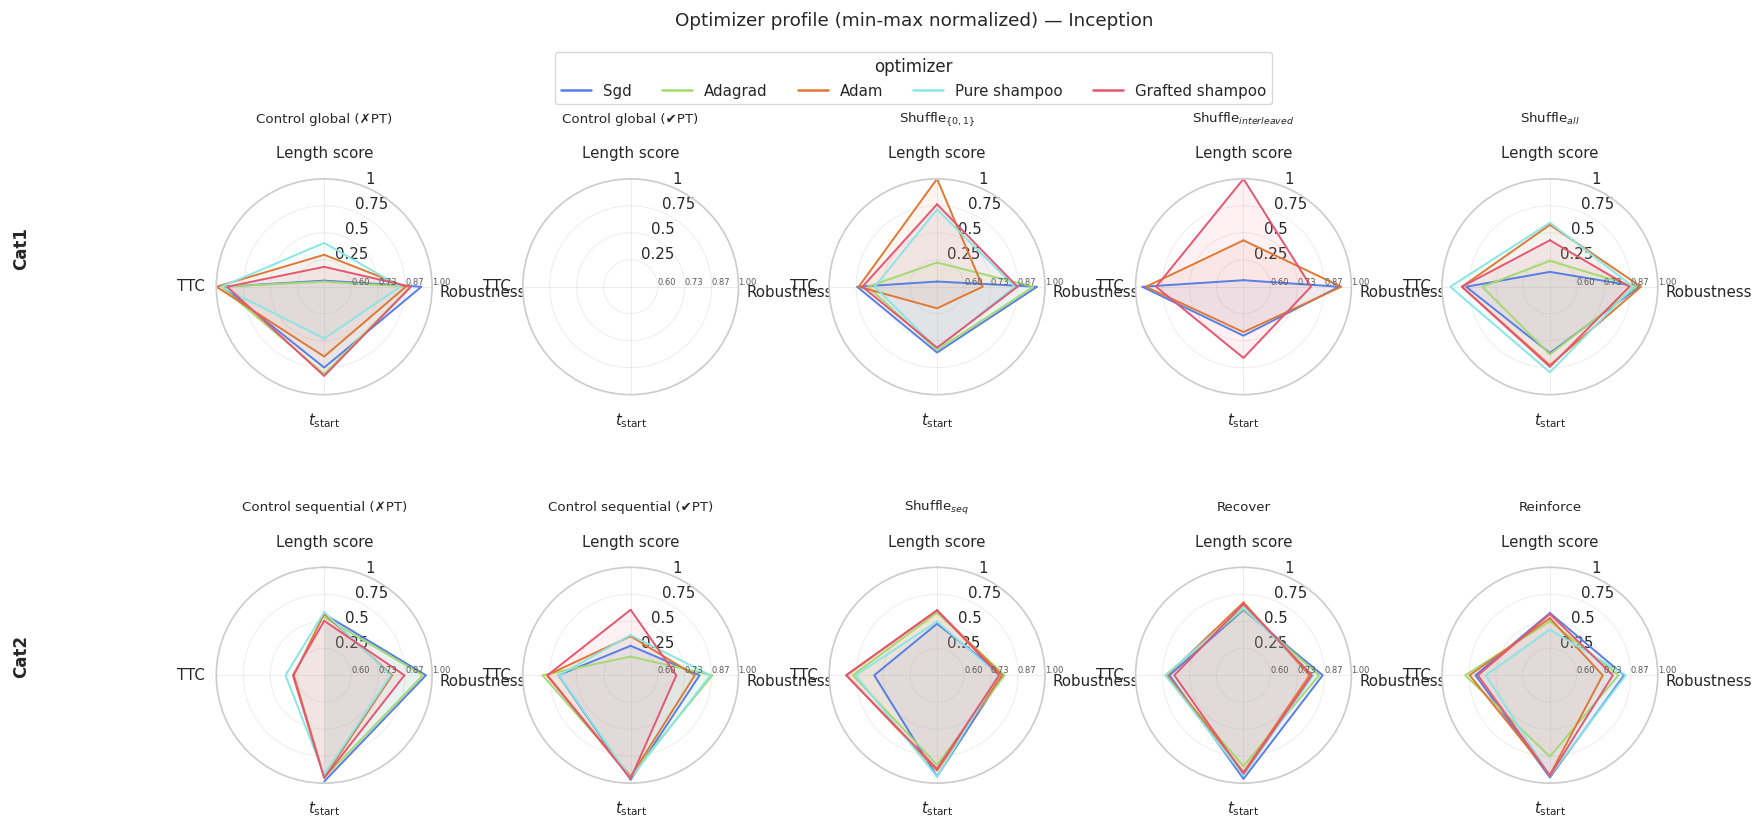

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/spider_profiles.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_spider_resnet.pdf


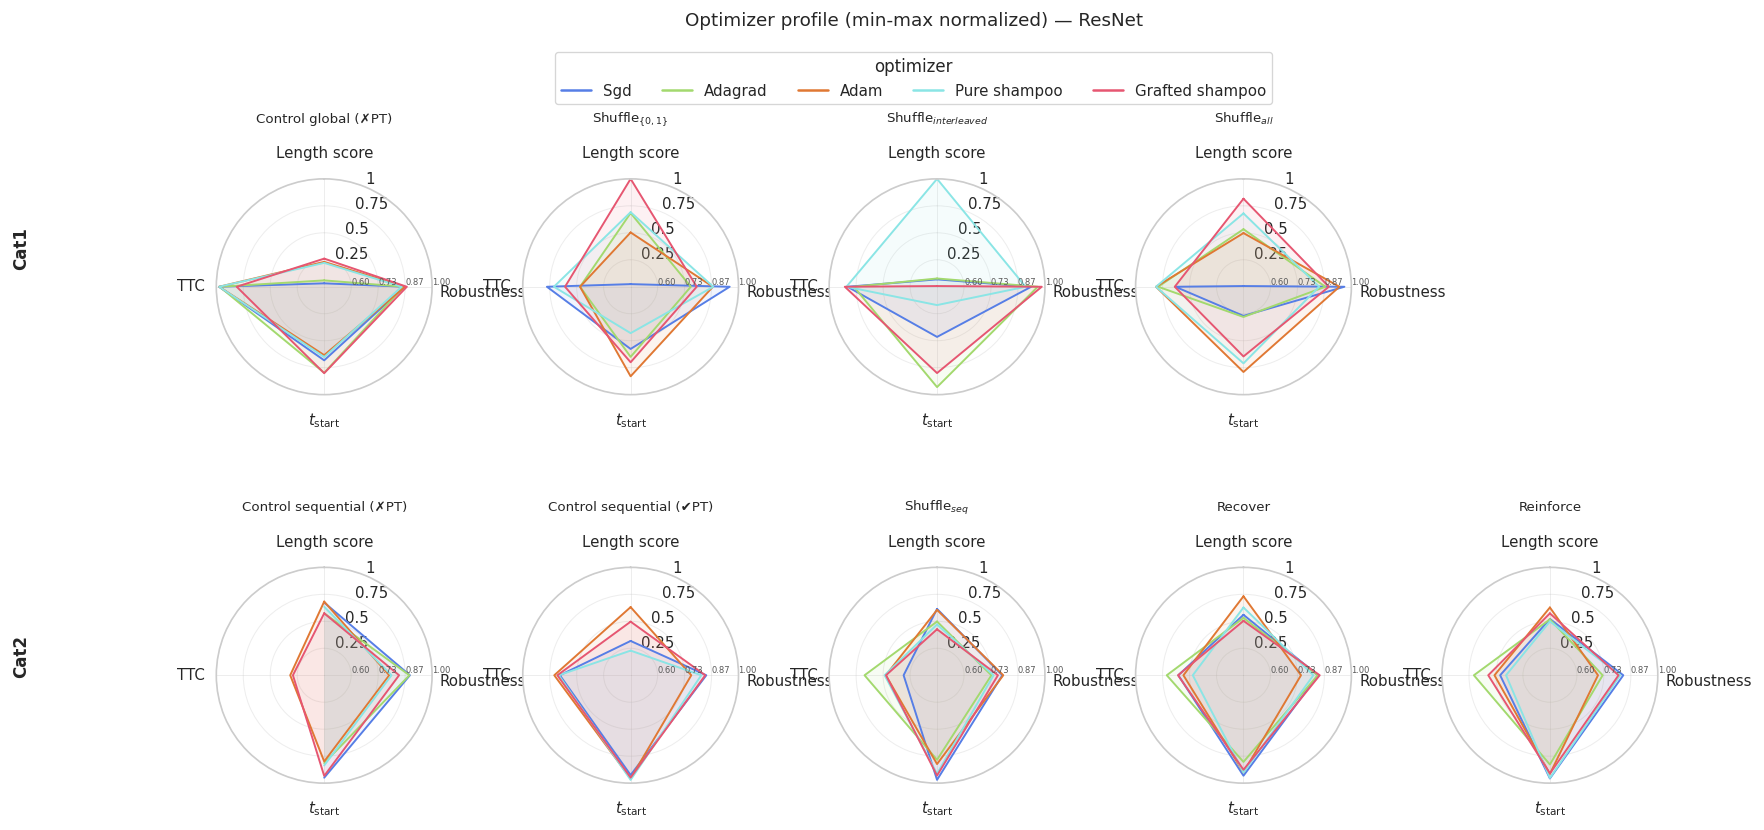

[<Figure size 1860x816 with 20 Axes>,
 <Figure size 1860x816 with 20 Axes>,
 <Figure size 1860x816 with 19 Axes>]

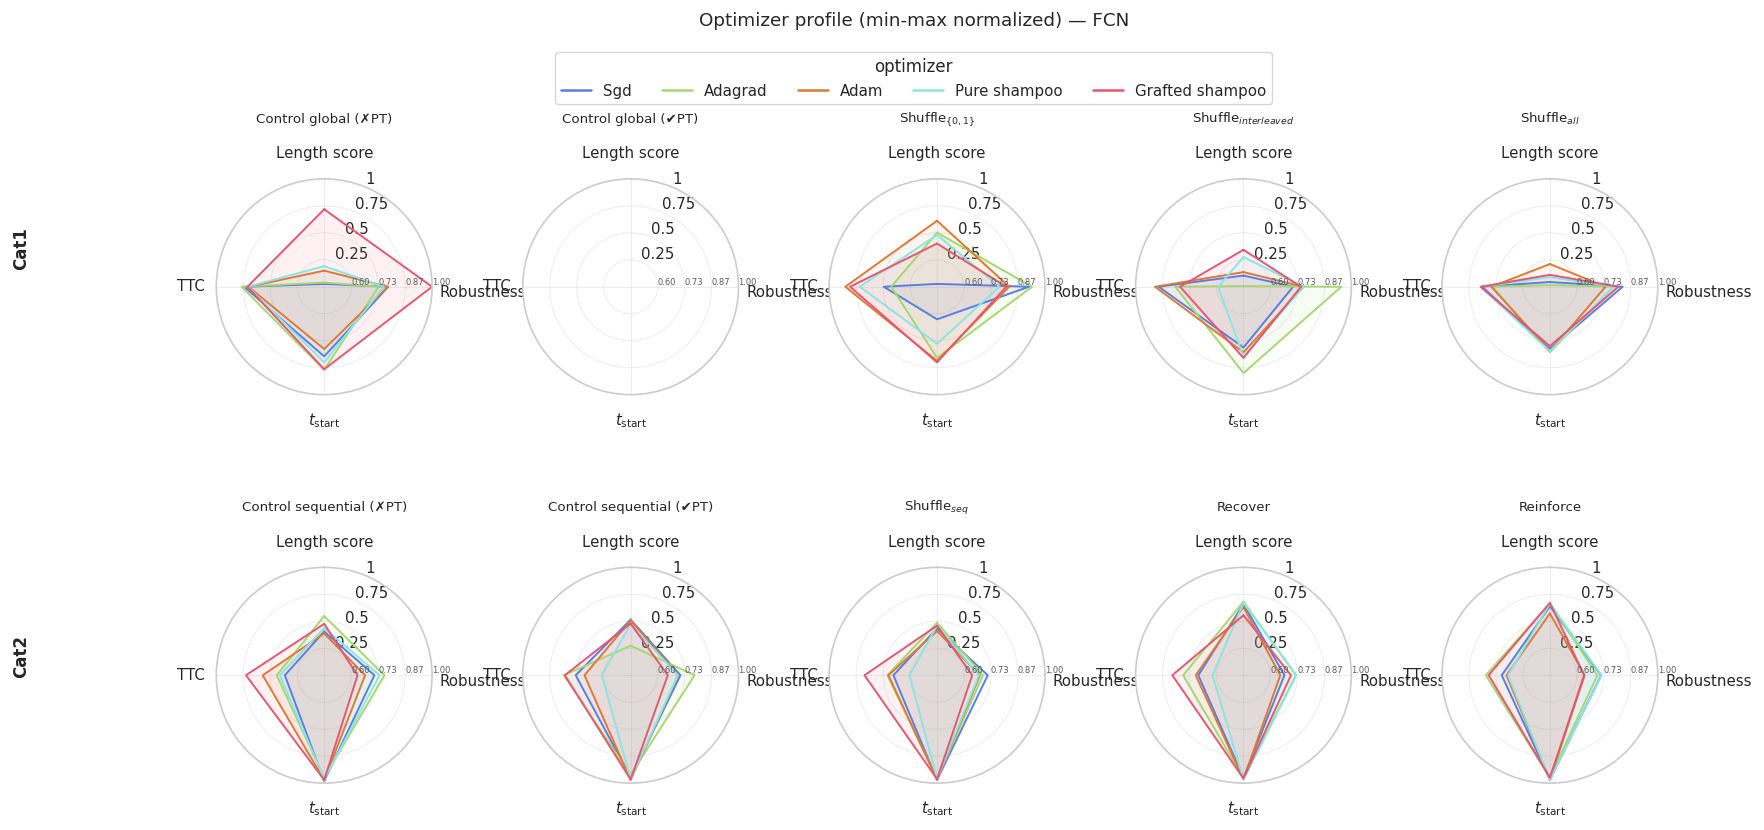

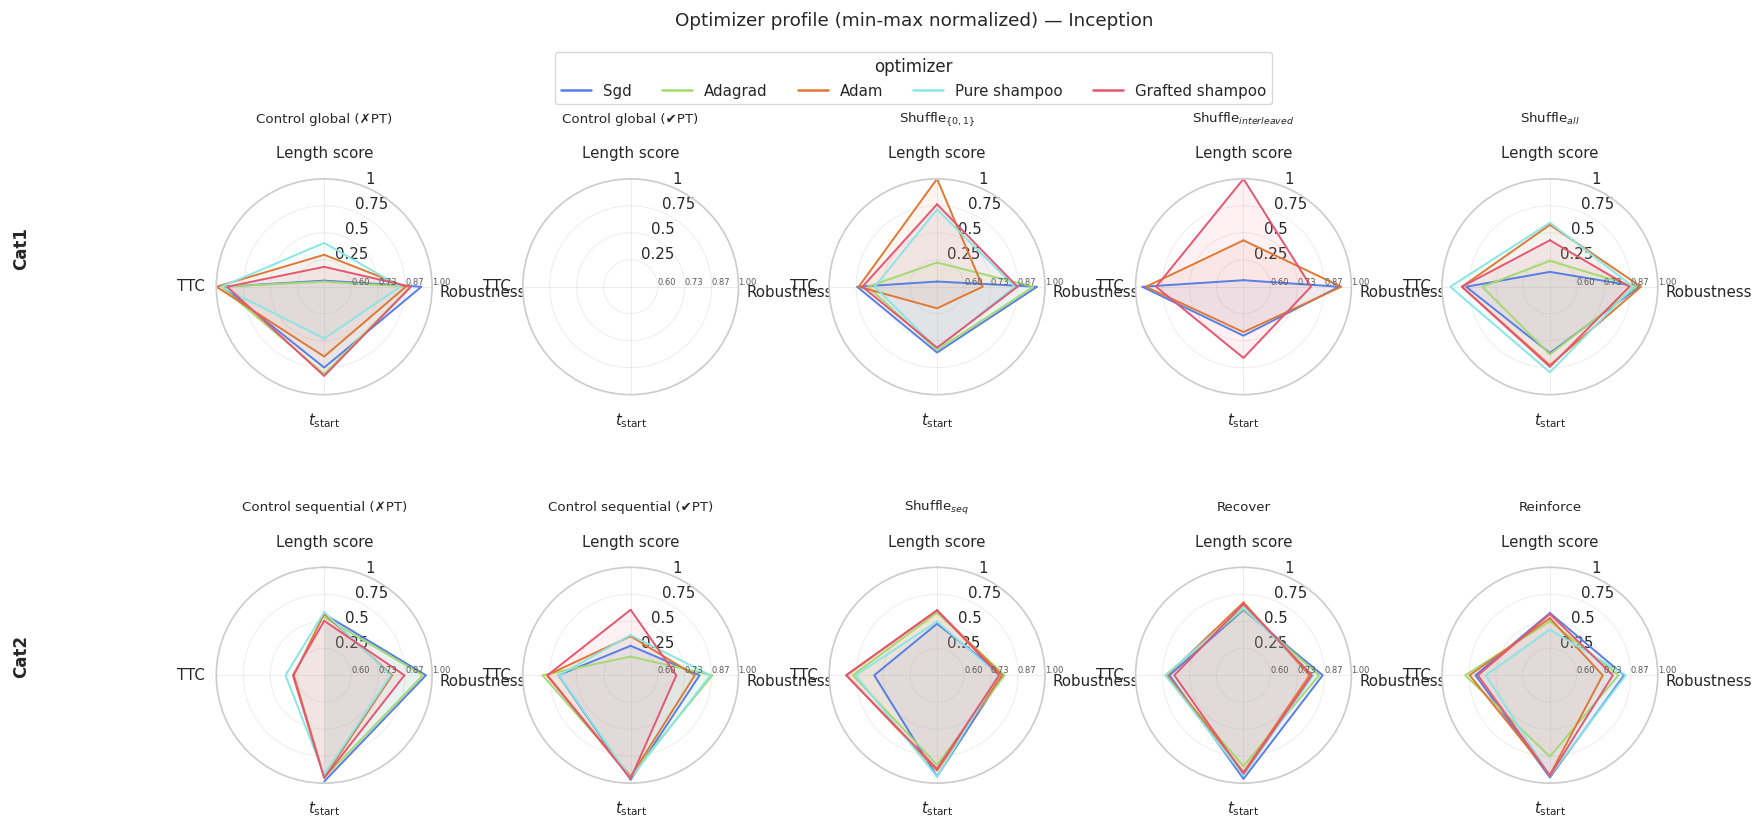

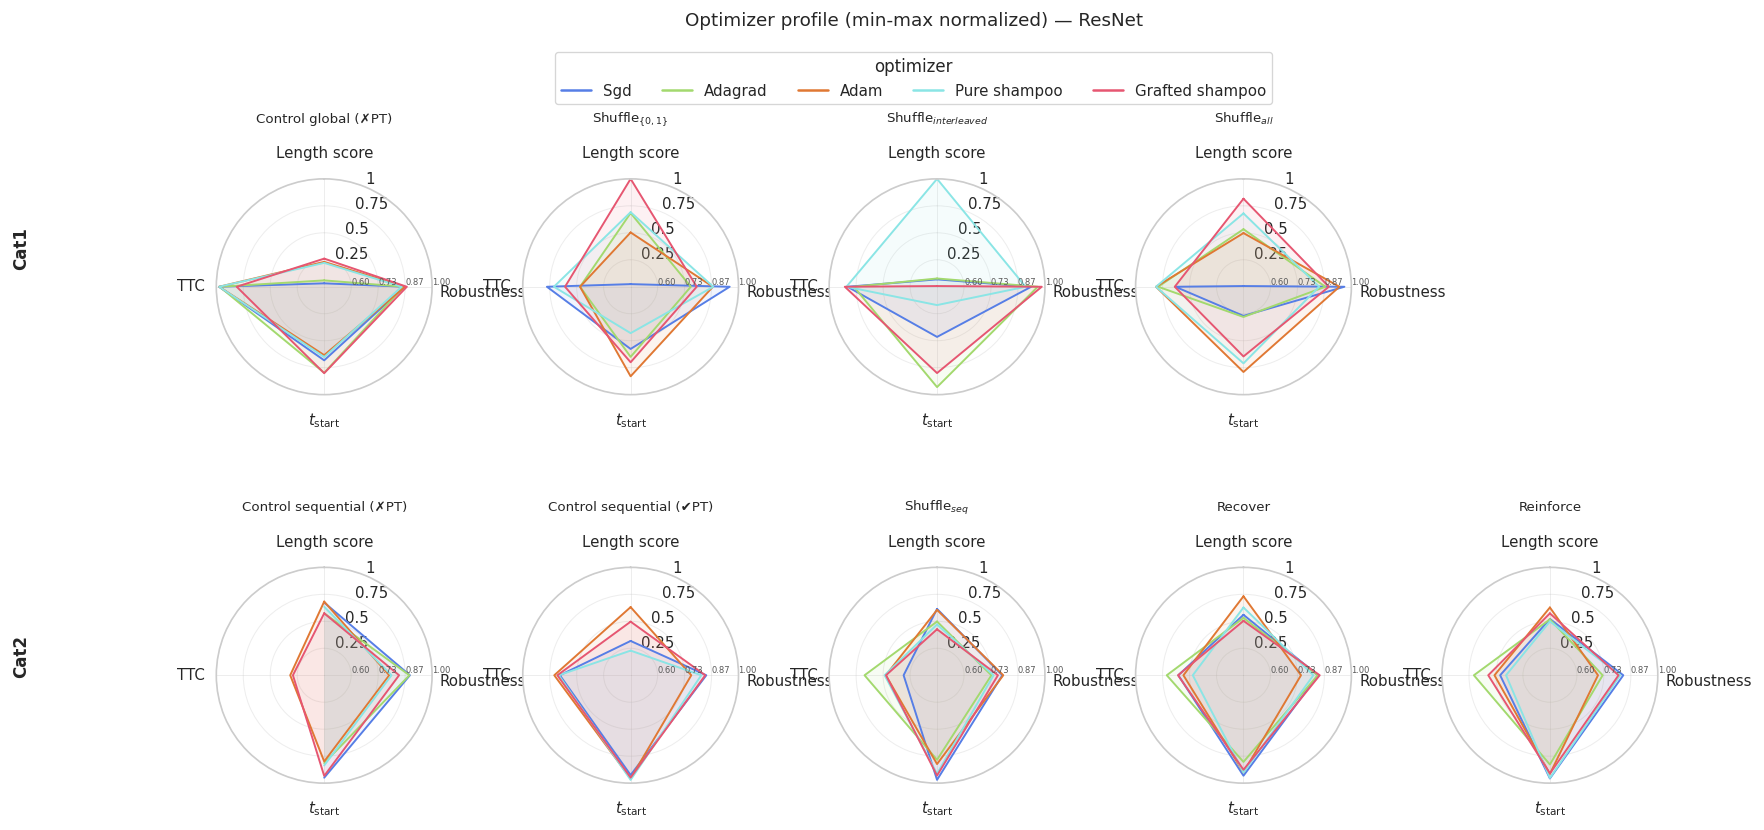

In [30]:
plot_report_spider_figure(
	spider_means,
	all_results,
	labels=LABELS,
	sort_experiment_names=_sort_experiment_display_names,
	plot_dir=PLOT_DIR,
	filename="report_spider.pdf",
	title="Optimizer profile (min-max normalized)",
	show = True,
	show_angle = False,
)

## 9b. Pooled spider (shuffle-seq / recover / reinforce)

One row × three columns (MNIST, Inception, ResNet). Each panel pools mean spider scores across shuffle-seq, Recover, and Reinforce (same scoring as §8).

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_spider_shuffle_recover_reinforce_pooled.pdf


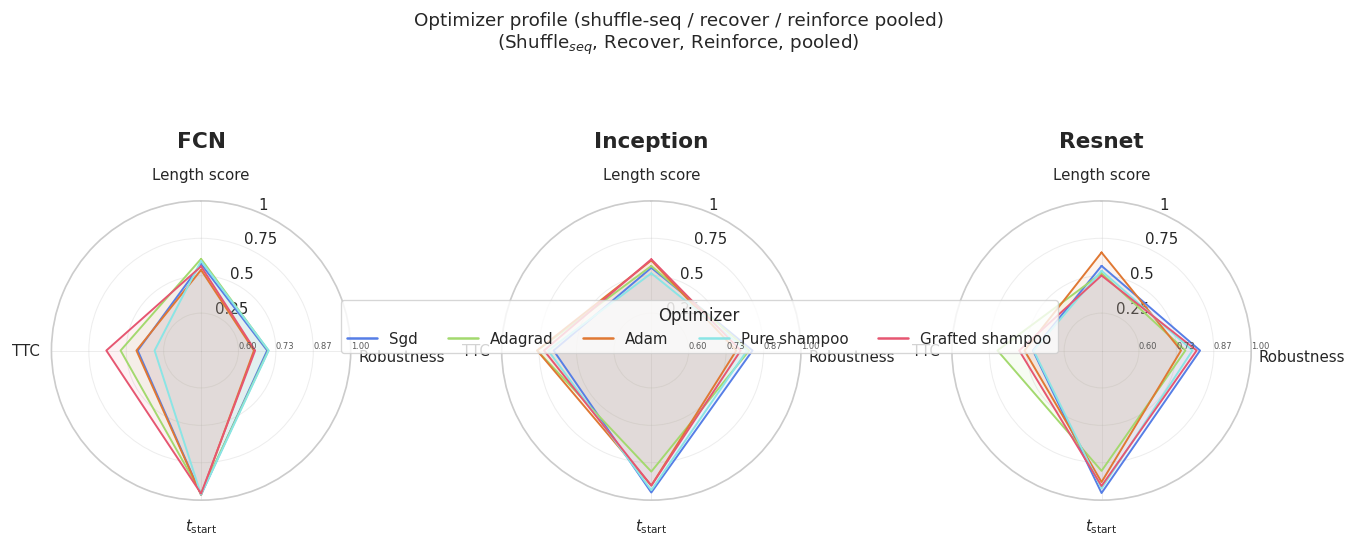

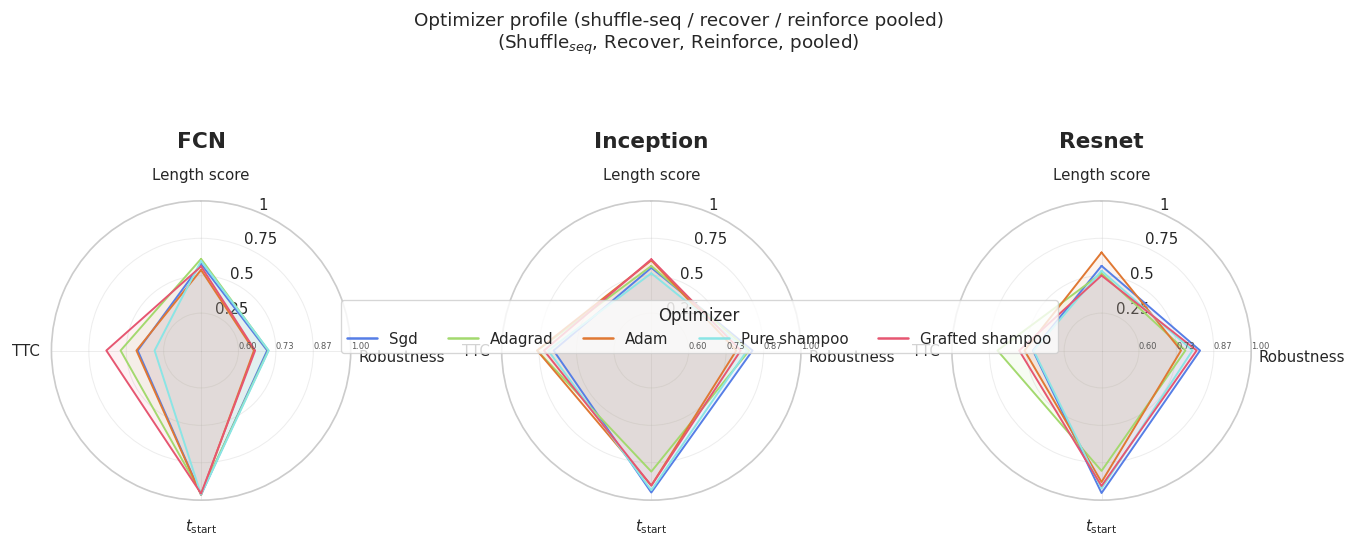

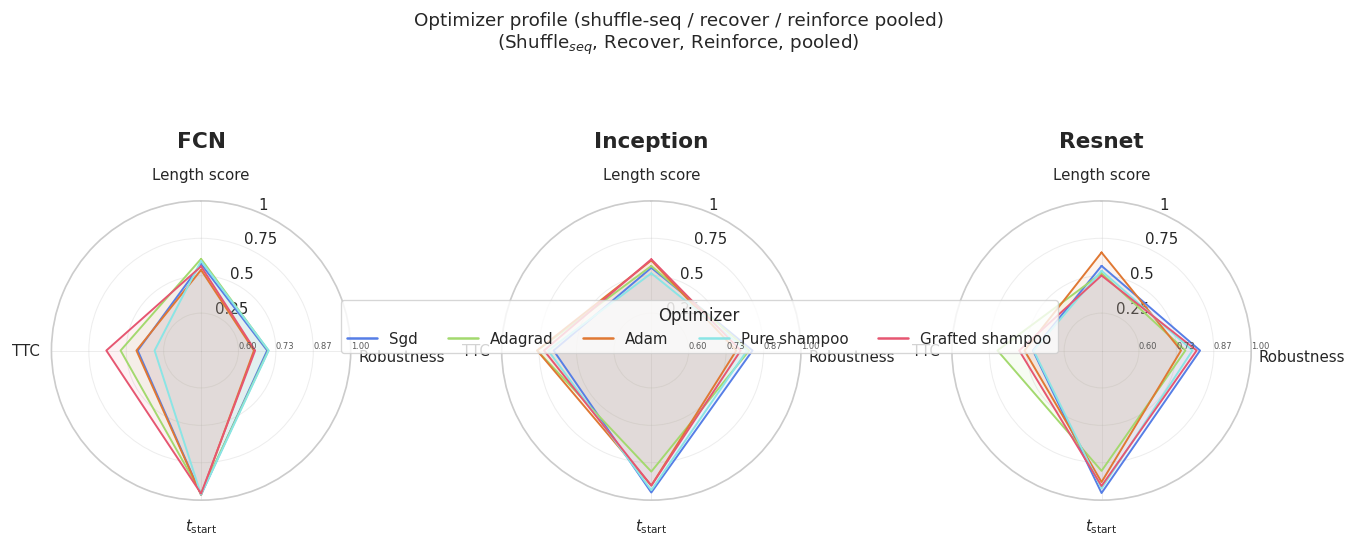

In [31]:
plot_report_spider_pooled_figure(
	spider_means,
	labels=LABELS,
	plot_dir=PLOT_DIR,
	filename="report_spider_shuffle_recover_reinforce_pooled.pdf",
	show=True,
    show_angle=False,
)

## 10. $t_\mathrm{start}$ comparison (Cat2 pooled)

Top row: pooled eCDF of $t_\mathrm{start}$ offset from novelty ($\text{Shuffle}_\mathrm{seq}$ + Recover + Reinforce), one column per model, with neuro BTSP / other reference curves.

Bottom row: per optimizer, left axis = AUC of the offset eCDF; right axis = two-sample Cramér–von Mises distance vs neuro BTSP (equal-weight pool of the two CDFs).

period_offset_df rows=11606


/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/final/report_plots/style.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_t_start_comparison.pdf


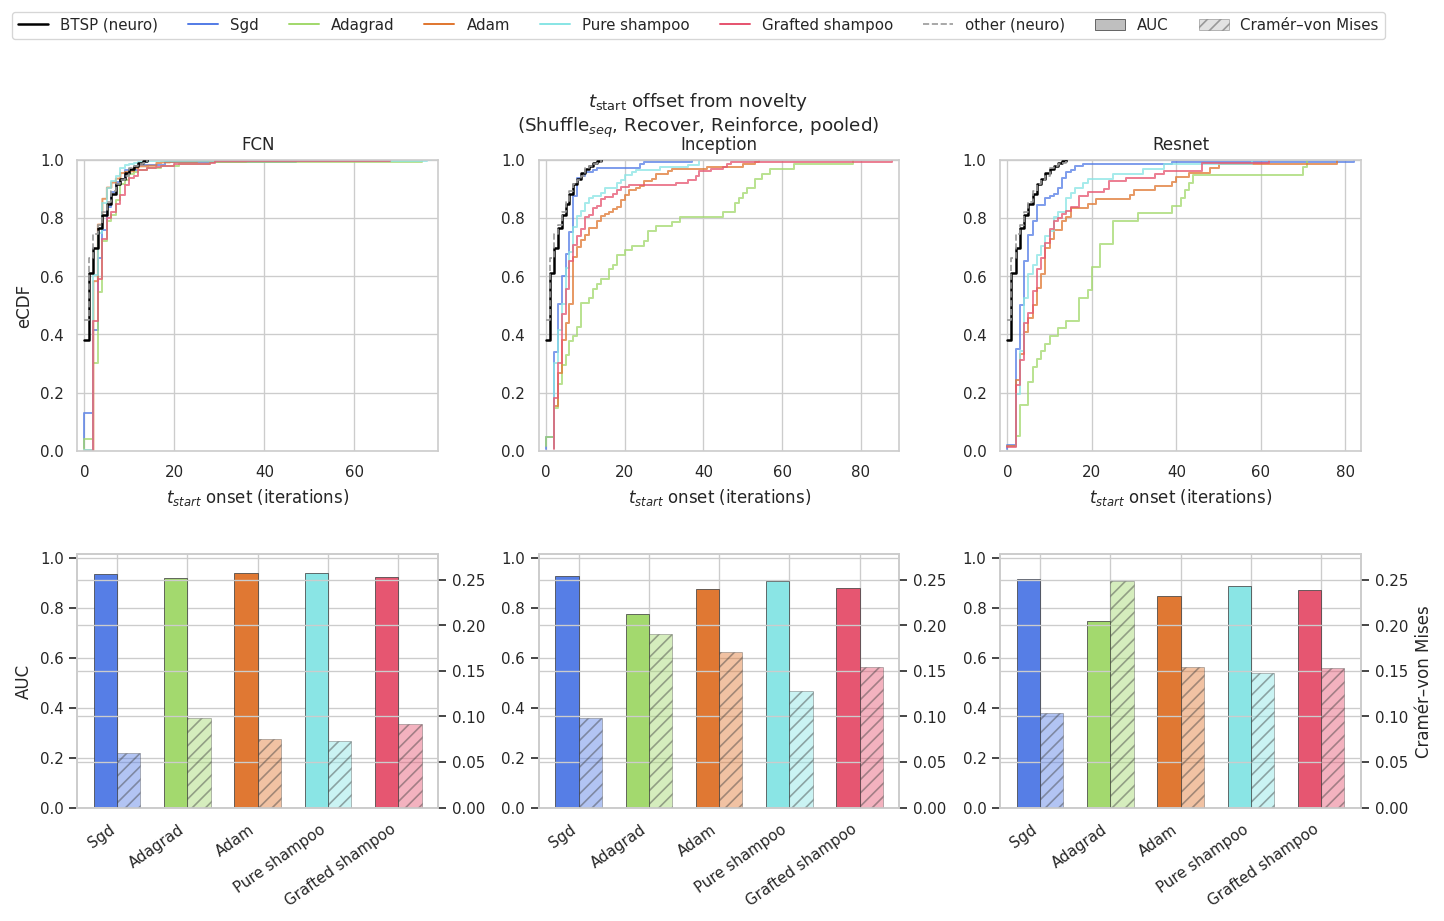

,model_id,optimizer_id,n,auc,cvm,cvm_p
0,dnn_5x64,sgd,116,0.933510,0.059758,0.0001
1,dnn_5x64,adagrad,143,0.920864,0.097892,0.0001
2,dnn_5x64,adam,520,0.937711,0.075252,0.0001
3,dnn_5x64,pure_shampoo,512,0.938599,0.073482,0.0001
4,dnn_5x64,grafted_shampoo,296,0.923647,0.092132,0.0001
5,inception_small_dnn_5x64,sgd,145,0.928397,0.098560,0.0001
6,inception_small_dnn_5x64,adagrad,61,0.774956,0.190489,0.0001
7,inception_small_dnn_5x64,adam,123,0.875590,0.170897,0.0001
8,inception_small_dnn_5x64,pure_shampoo,113,0.906894,0.127301,0.0001
9,inception_small_dnn_5x64,grafted_shampoo,126,0.880089,0.153672,0.0001


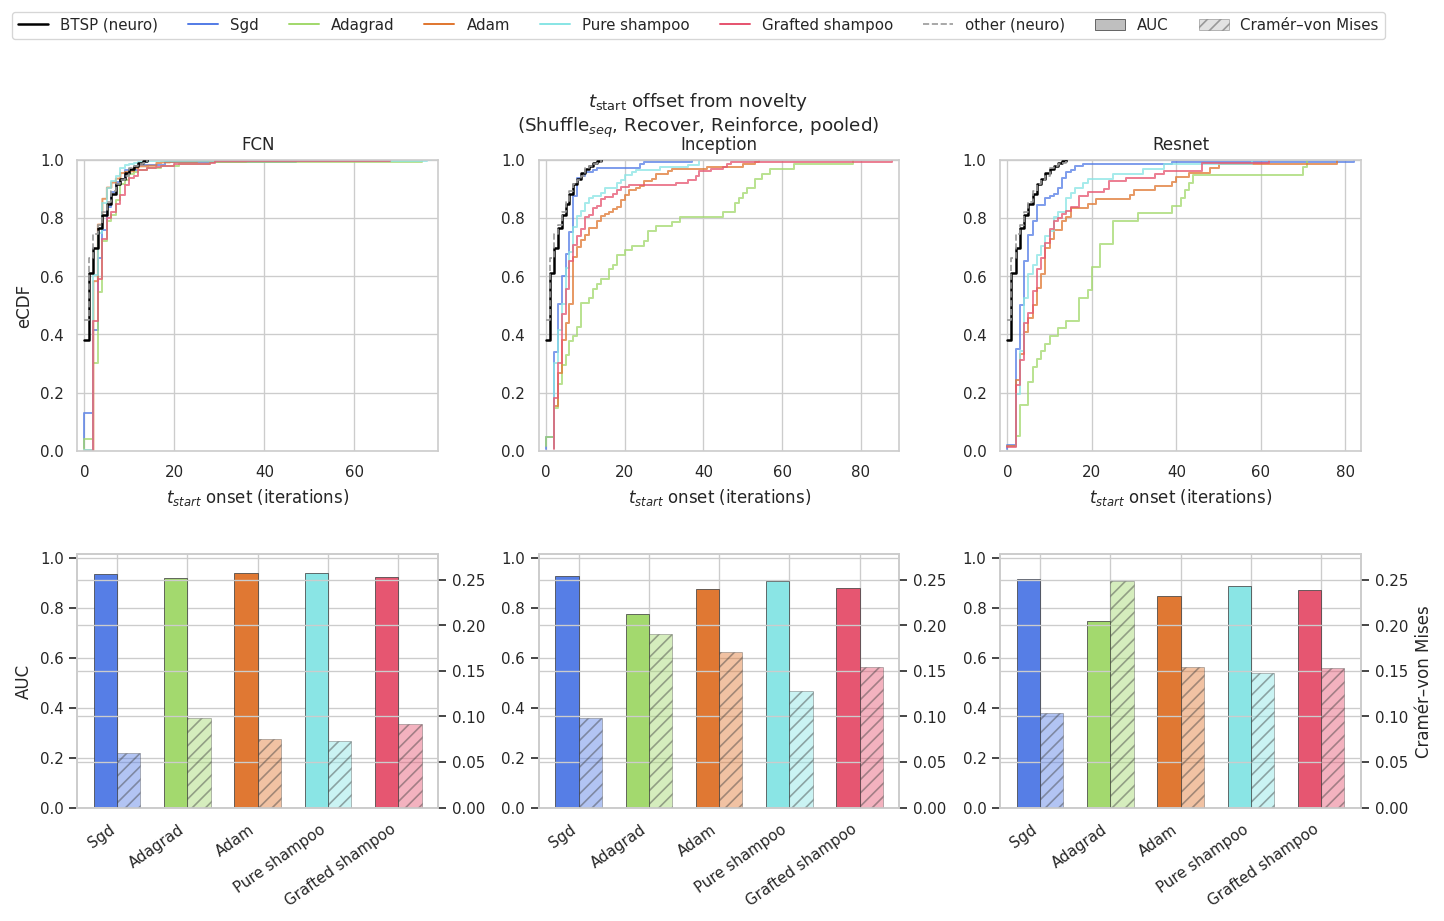

In [32]:
NEURO_EXPERIMENTAL_PATH = Path("parsed_bars.csv")
assert NEURO_EXPERIMENTAL_PATH.is_file(), (
	f"neuro ground-truth file missing: {NEURO_EXPERIMENTAL_PATH.resolve()}"
)
neuro_experimental_bars = load_neuro_experimental_bars(NEURO_EXPERIMENTAL_PATH)

period_offset_df = build_period_novelty_offset_df(all_results, rename_experiments)
print(f"period_offset_df rows={len(period_offset_df)}")

_, t_start_metrics = plot_report_t_start_comparison_figure(
	period_offset_df,
	neuro_experimental_bars,
	labels=LABELS,
	plot_dir=PLOT_DIR,
	filename="report_t_start_comparison.pdf",
	title=r"$t_{\mathrm{start}}$ offset from novelty",
	show=True,
)
display(t_start_metrics)

## 11. Layer-wise analysis

Pooled over Cat2 non-control experiments ($\text{Shuffle}_\mathrm{seq}$, Recover, Reinforce). One column per model (MNIST / Inception / ResNet).

**Plot A:** top row = % neurons with BTSP periods per layer; bottom row = BTSP period % per layer. Grouped bars by optimizer; dashed line = group-mean linear fit ($R^2$ annotated); colored lines = per-optimizer fits.

**Plot B:** top row = mean BSS (`total_score`) per layer (same pool); bottom row = one violin per layer pooling all optimizers (all period samples).

/home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/io.py:57: DtypeWarning: Columns (0: layer_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(str(path))


Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_layerwise_btsp_pct.pdf


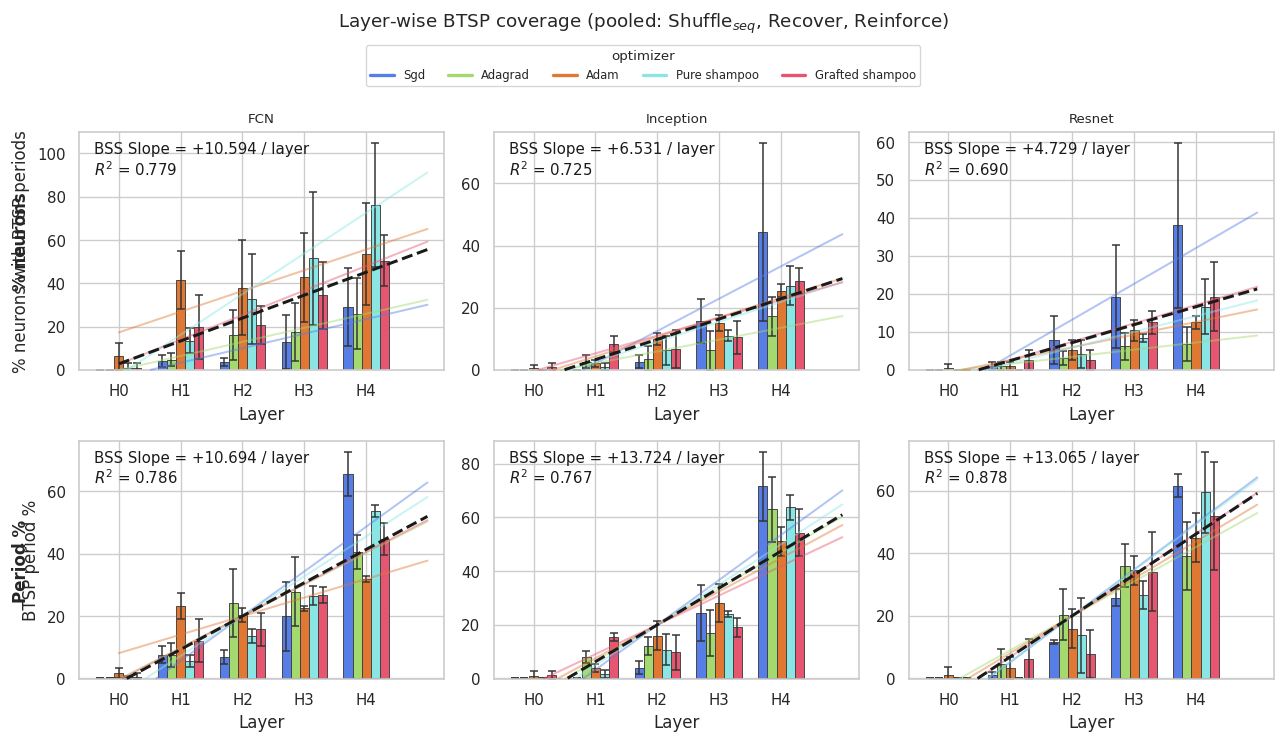

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/report_layerwise_bss.pdf


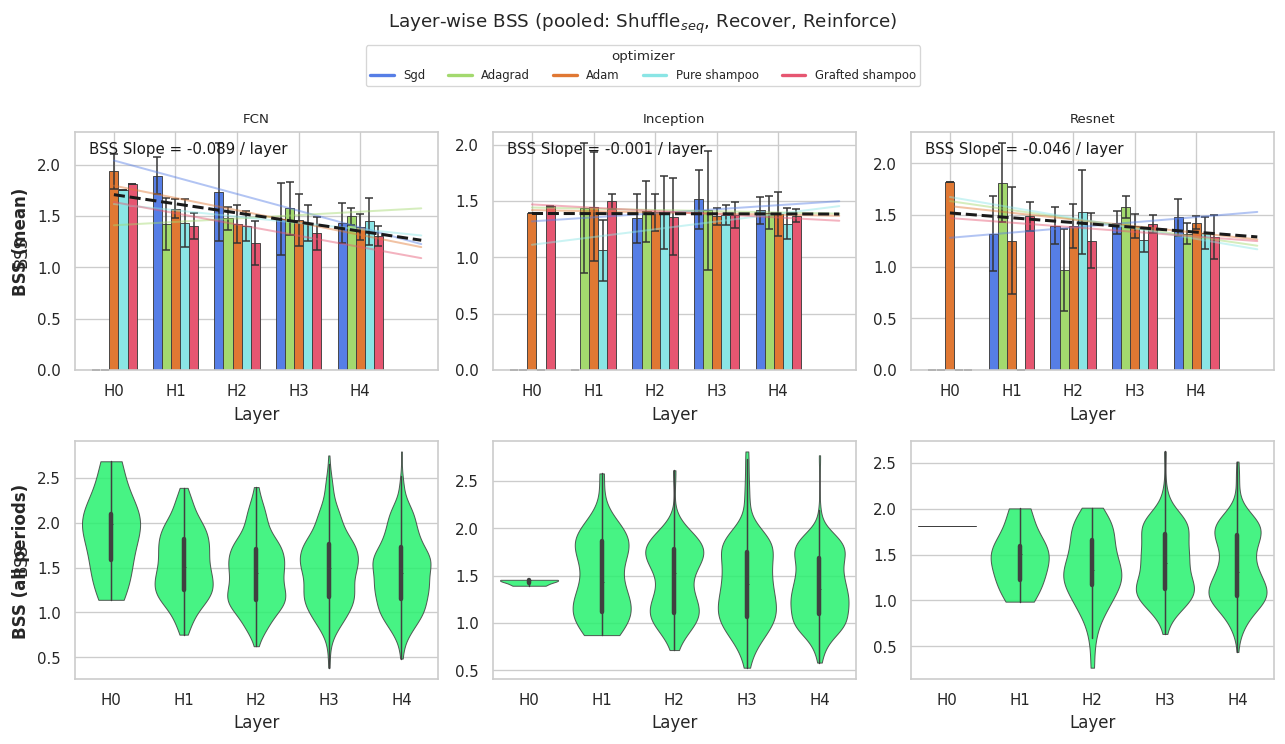

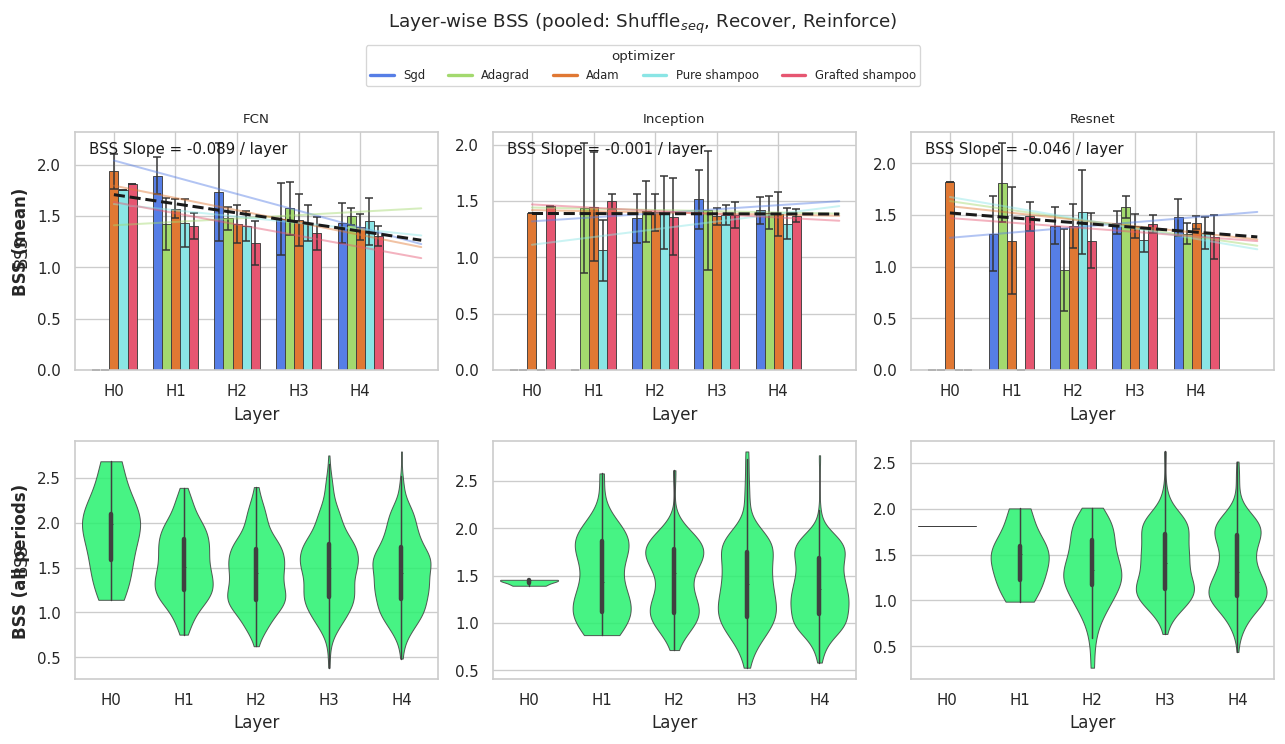

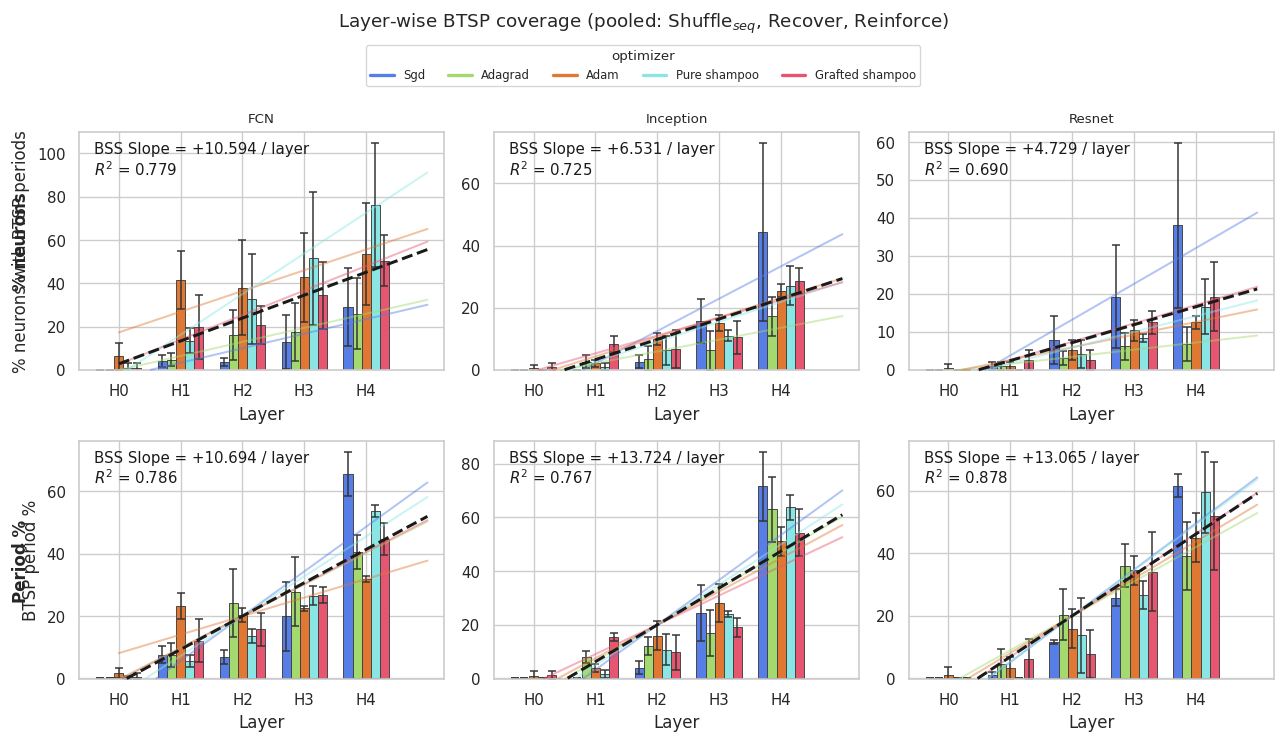

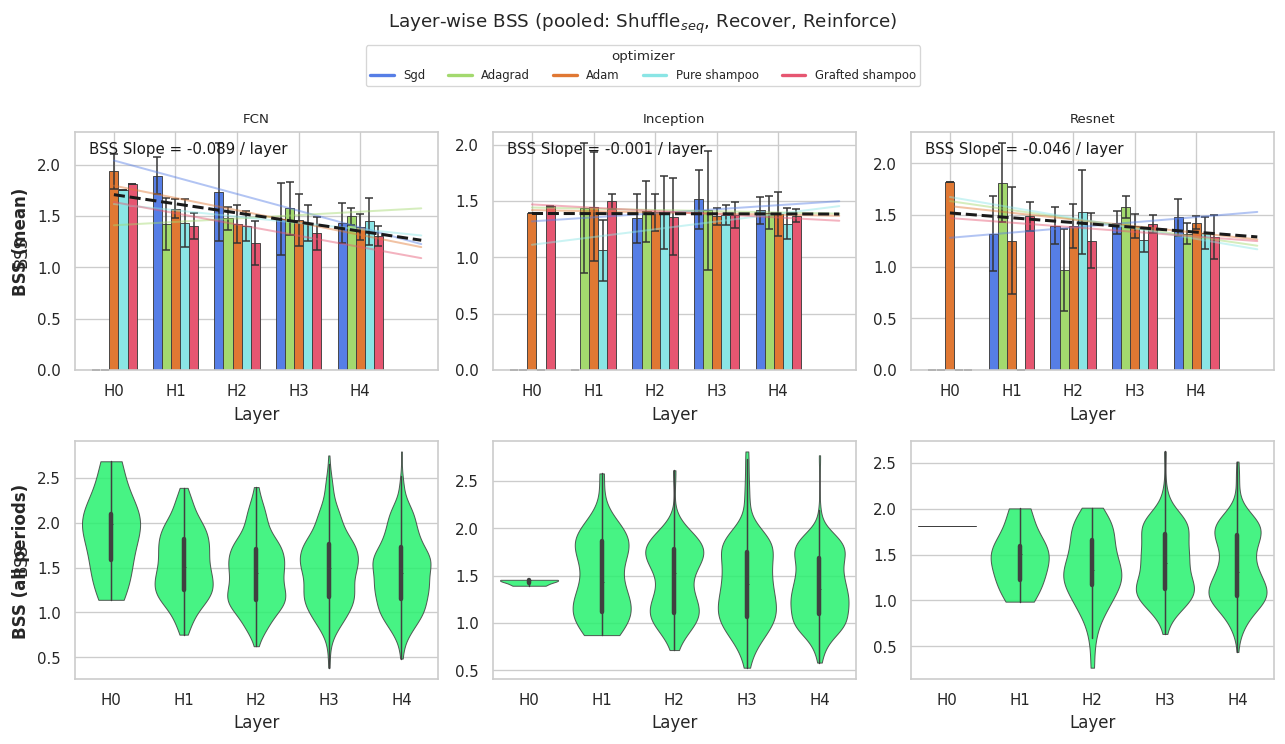

In [33]:
plot_report_layerwise_btsp_pct_figure(
	all_results,
	rename_experiments,
	labels=LABELS,
	plot_dir=PLOT_DIR,
	filename="report_layerwise_btsp_pct.pdf",
	show=True,
)

plot_report_layerwise_bss_figure(
	all_results,
	rename_experiments,
	labels=LABELS,
	plot_dir=PLOT_DIR,
	filename="report_layerwise_bss.pdf",
	show=True,
)

## Training Losses

Windowed pretrain curves (FCN / Inception / ResNet) are **always shown and saved**.

Per-experiment training losses (peaks + late-phase thresholds, as in `time_to_stabilization.ipynb`) are saved to `losses/`; set `SAVEplot = "plot"` below to also display them inline.

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/losses/pretrain_dnn_mnist.pdf


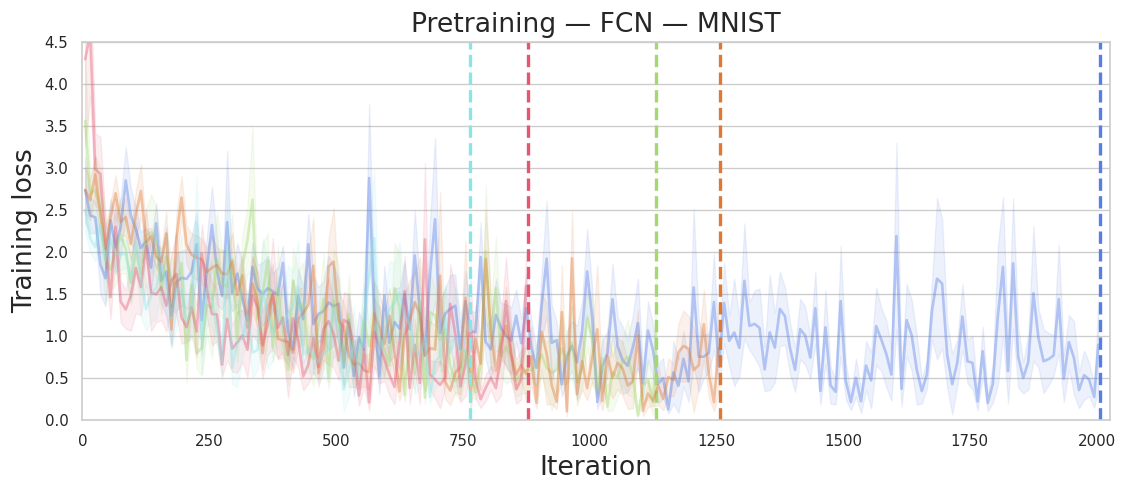

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/losses/pretrain_inception_cifar10.pdf


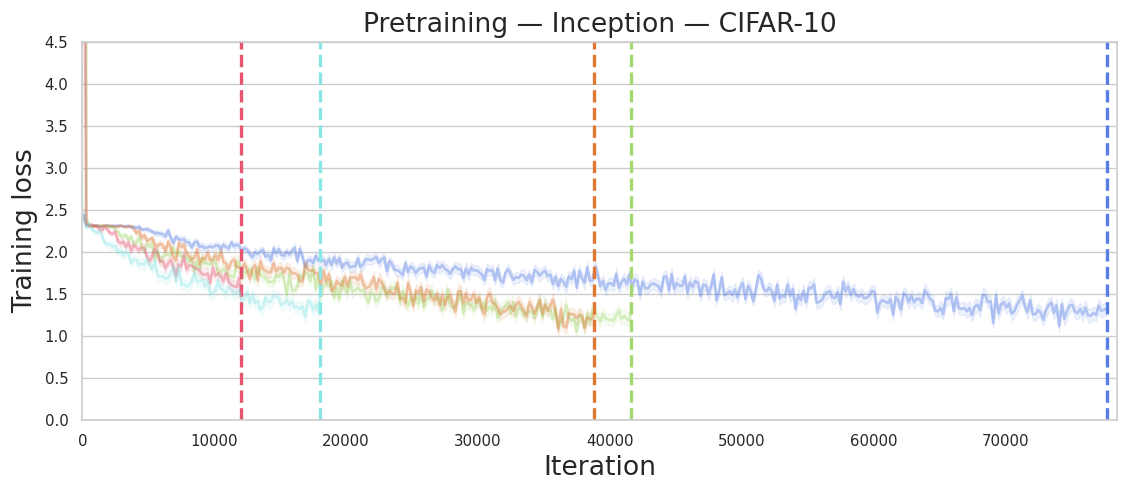

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/losses/pretrain_resnet_cifar10.pdf


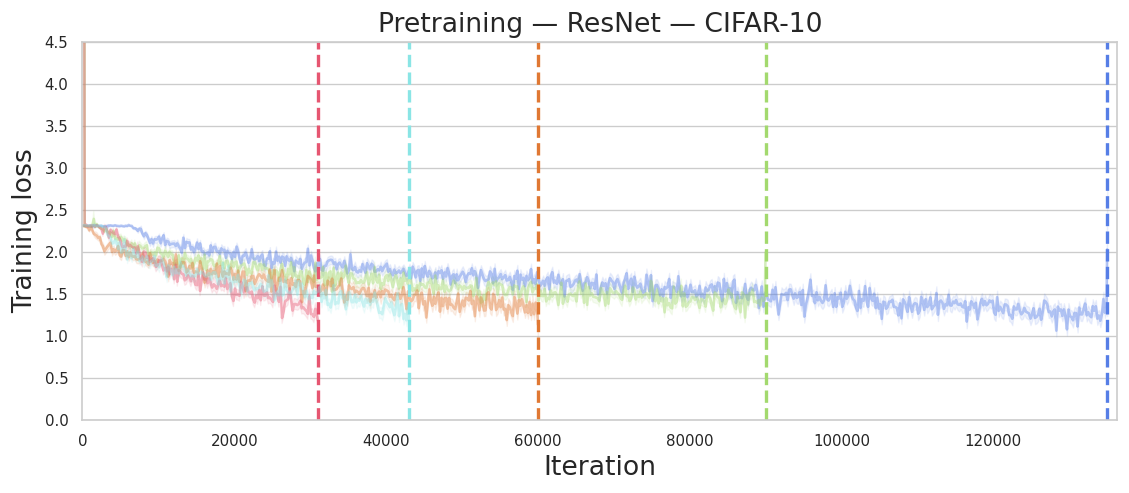

Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/losses/mnist_cat1_control_global.pdf
Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/losses/mnist_cat1_constrained_digits01.pdf
Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/losses/mnist_cat1_interleaved_digits01.pdf
Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/losses/mnist_cat1_shuffle_all.pdf
Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/losses/mnist_cat2_control_sequential_nopre.pdf
Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/losses/mnist_cat2_control_sequential_pre.pdf
Saved /home/garvalov/thesis/plateau_optimizer/network_analyzer/analysis/notebooks/local/save/plots/report/losses/mn

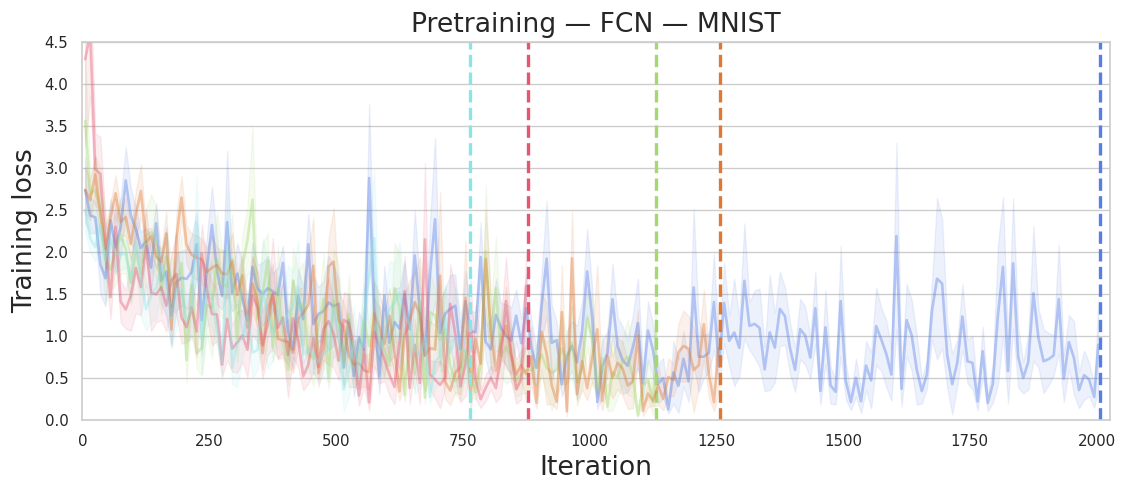

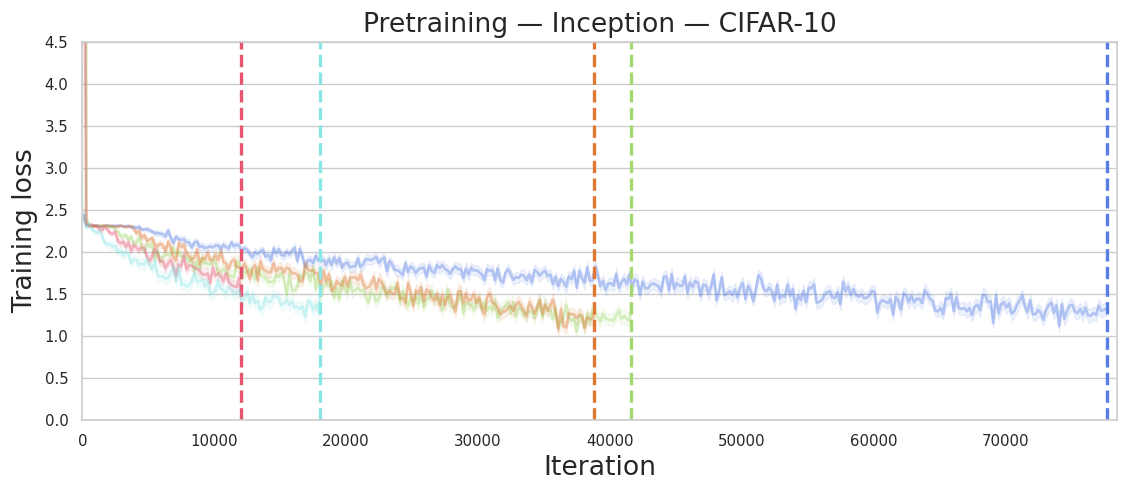

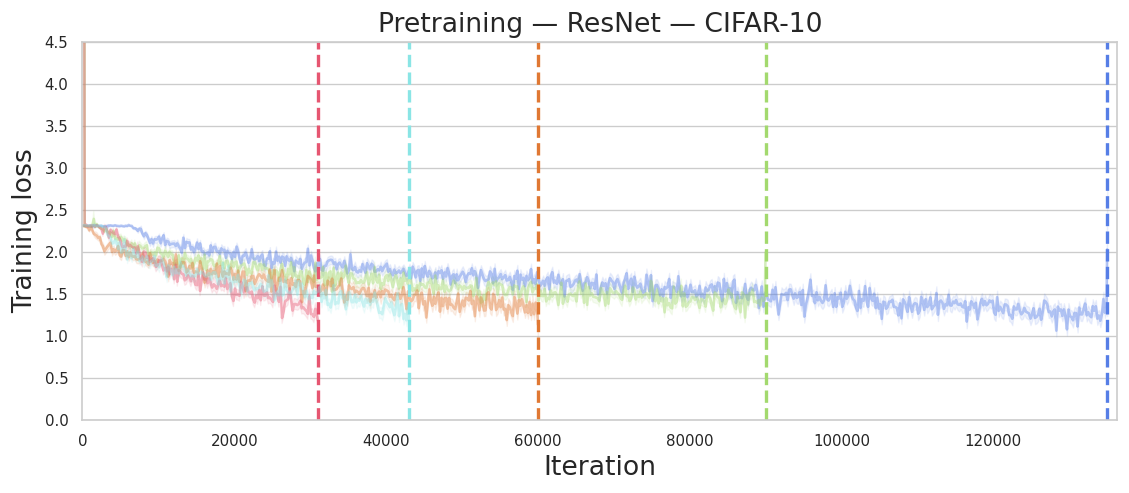

In [34]:
SAVEplot = "save"  # or "plot"

plot_report_pretrain_loss_figures(
	PROJECT_ROOT,
	PLOT_DIR,
	save=True,
	show=True,
)

plot_report_stabilization_loss_figures(
	all_results,
	all_trees,
	rename_experiments,
	PLOT_DIR,
	show=SAVEplot == "plot",
	save=True,
)
